In [1]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import pickle
import math
import scipy
from pathlib import Path
import sys
import os
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import ScalarFormatter
from copy import deepcopy
sys.path.append("../src")
from custom_distance import KL, conditionKL
import itertools


import plotly.express as px

import plotly.io as pio
pio.renderers.default = 'iframe' # or 'notebook' or 'colab' or 'jupyterlab' iframe

from plotly.express.colors import sample_colorscale

import plotly.graph_objects as go


warnings.filterwarnings("ignore")


def get_regression(x, y):
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


def get_coefLog10(x, y):
    x = np.log10(x)
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


In [ ]:
!ls -lrt ../output/regression_onlyAlpha_Train_1_SHACBalanceAlpha

In [ ]:
!ls -lrt ../output/regression_ReSampling_HateSpeechBalanceAlpha

In [ ]:
!ls -lrt ../output/regression_ReSampling_SHACBalanceAlpha

In [ ]:
!ls -lrt ../output/tmpData/SHAC

In [ ]:
!ls -lrt ../output/tmpData/HateSpeech

In [2]:
# save

# with open("../output/regressionSHAC/05_02_400_L2_C5_V1.pkl", "wb") as f:
#     pickle.dump(df_eval, file=f)
    
# with open(f"../output/regressionInverseSHAC_MIMIC_UW/binaryUnigram_02_05_500_l2_C1_V100.pkl", "rb") as f:
# with open(f"../output/regressionSHAC/binaryUnigram_05_02_500_l2_C1_V1.pkl", "rb") as f:


##### SHAC

# fname="../output/regressionSHAC/binaryUnigram_0.3_0.3_500_l2_C1_V10"
# fname="../output/regressionSHAC/binaryUnigram_05_02_500_l2_C1_V10"
# fname="../output/regressionSHAC/Sentence-BERT_05_02_500_l2_C1_V10" ## AMIA Plot
# fname="../output/regressionSHAC/LLaMaAverage_0.5_0.2_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_12720_ntest_200_l2_C1_V10" ## Balanced!
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_l2_C1_V10" ## Balanced!
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverage_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/DistilBERT_12720_ntest_200_l2_C1_V10"

# fname="../output/regressionSHAC/Clinical-BERT_0.5_0.2_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_7B_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_13B_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_70B_8Quant_ntest_200_l2_C1_V10"


# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-32_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-32_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-64_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-32_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_0.5_0.2_500_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_ntest_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha_SimplePermuteAverage/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha_SimplePermute_TestAverageByProportion/Sentence-BERT_ntest_500_l2_C1_V10"

# fname = "../output/DistilBERT_SHACBalanceAlpha_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_500"
# fname = "../output/DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_5/DistilBERT_ntest_500"




# fname = "../output/tmpData/LoraPredict/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict_Original_Target/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetNorm/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict_Original_Target/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetNorm/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetFroNorm/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetFroNorm/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1_Added/set-1355-quantization-epoch3-llama-2-13B-loraR-8-gamma_1-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.1_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.2_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.8_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_2.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_2_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_3.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_3_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_1.0_Lambda2_0.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_1.0-lambda2_0.5-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_2.0_Lambda2_1.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_2.0-lambda2_1.0-added_ntest_500_setting_1_20"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_1.0_Lambda2_0.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_1.0-lambda2_0.0-added_ntest_500_setting_1_20"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_500-pct_1_20"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_500-pct_1_20"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_500-pct_1_15"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_5"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-pct_1_5"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-pct_1_5"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_1_wrongSet"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-pct_1_1_wrongSet"

# fname = '../output/regression_onlyAlpha_Train_1_SHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'
# fname = '../output/regressionStratifiedSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'
# fname = '../output/regressionOversamplingSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'
# fname = '../output/regression_Sampling_0.8_SHACBalanceAlpha/Multiplier_0.8-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.2-p_pos_train_z1_target_0.2-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.4-p_pos_train_z1_target_0.4-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.4-p_pos_train_z1_target_0.4-Sentence-BERT-ntest_200-l2-C1-V10'
# fname = '../output/regression_ReSampling_SHACBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.6-p_pos_train_z1_target_0.6-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_Augmentation_SHACBalanceAlpha/mixup_4-augPercentage_0.1-binaryUnigram-ntest_200-l2-C1-V10'
# fname = '../output/regression_Augmentation_SHACBalanceAlpha/mixup_4-AugUP-binaryUnigram-ntest_200-l2-C1-V10'


# fname = '../output/regressionSHACBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-Sentence-BERT-ntest_200-l2_C1-V10'
# fname = '../output/regressionSHACBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10'
# fname = '../output/SVM_SHACBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-Sentence-BERT-ntest_200-l2_C1-V10'
# fname = '../output/SVM_SHACBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10'


# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_4.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-2800-quantization-epoch3-llama-2-7B-loraR-8-lambda1_4.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-13755-quantization-epoch3-llama-2-7B-loraR-8-lambda1_4.0-lambda2_1.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.3-lambda2_0.3-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.3-lambda2_0.3-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.3-lambda2_0.3-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-lambda3_0.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-lambda3_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-lambda3_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.5-lambda3_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.5-lambda3_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.5-lambda3_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.6-lambda2_0.3-lambda3_0.3-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.6-lambda2_0.3-lambda3_0.3-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.6-lambda2_0.3-lambda3_0.3-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-lambda3_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-lambda3_1.0-added-ntest_200-Runs_5"


# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_ReverseSource/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_proj/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-lambda3_1.0-added-Proj_RS-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-lambda3_0.5-added-Proj_S-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-lambda3_1.0-added-Proj_RS-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-lambda3_0.5-added-Proj_S-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_proj/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.3-lambda2_0.3-lambda3_1.0-added-Proj_RS-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.3-lambda2_1.0-lambda3_0.3-added-Proj_S-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.3-lambda2_0.3-lambda3_1.0-added-Proj_RS-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.3-lambda2_1.0-lambda3_0.3-added-Proj_S-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_norm_proj/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_RS-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_norm_proj/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_S-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_norm_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_RS-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_norm_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_S-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_norm/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_norm/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_norm/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-lambda3_0.25-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-lambda3_0.25-added-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-lambda3_0.25-added-ntest_200-Runs_5"

# fname = "../output/tmpData/SHAC_proj/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-lambda3_0.5-added-Proj_S-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-lambda3_1.0-added-Proj_RS-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-lambda3_0.5-added-Proj_S-ntest_200-Runs_5"
# fname = "../output/tmpData/SHAC_proj/Eval-set-6114-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-lambda3_1.0-added-Proj_RS-ntest_200-Runs_5"


# dataset_name = 'SHAC'


##############  HateSpeech
fname = "../output/regressionHateSpeech/Sentence-BERT_0.6_0.1_500_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_0.6_0.1_500_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_ntest_5000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_1244_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_2234_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_75_ntest_1000_l2_C1_V10" ## Balanced
# fname = "../output/regressionHateSpeechBalanceAlpha/DistilBERT_75_ntest_1000_l2_C1_V10" ## Balanced
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_7B_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_13B_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_70B_8Quant_ntest_1000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_7B_Permute_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermute/Sentence-BERT_ntest_1000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermuteAverage/Sentence-BERT_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermute_TestAverageByProportion/Sentence-BERT_ntest_1000_l2_C1_V10"

# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_RandomPermute_ShorterVersion_1_5/DistilBERT_ntest_1000"
# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_1000"
# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_1000"

# fname = '../output/regressionStratifiedHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10'

# fname = '../output/regressionOversamplingHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10'
# fname = '../output/regression_Sampling_0.8_HateSpeechBalanceAlpha/Multiplier_0.8-binaryUnigram-ntest_1000-l2-C1-V10'
# fname = '../output/regression_ReSampling_HateSpeechBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.2-p_pos_train_z1_target_0.2-Sentence-BERT-ntest_1000-l2-C1-V10'
# fname = '../output/regression_ReSampling_HateSpeechBalanceAlpha/Multiplier_1-p_pos_train_z0_target_0.6-p_pos_train_z1_target_0.6-binaryUnigram-ntest_200-l2-C1-V10'

# fname = '../output/regression_Augmentation_HateSpeechBalanceAlpha/mixup_4-AugUP-binaryUnigram-ntest_1000-l2-C1-V10'


# fname = '../output/tmpData/HateSpeech/OriginalWeightsEdited-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-pct_1_25'
# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5'

# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_1000-Runs_5'

# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_1000-Runs_5'


# fname = '../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_1000-Runs_5'
# fname = '../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_1000-Runs_5'

# fname = "../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_1000-l2_C1-V10"
# fname = '../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-binaryUnigram-ntest_1000-l2_C1-V10'

# fname = '../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-Sentence-BERT-ntest_1000-l2_C1-V10'
# fname = '../output/regressionHateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_1000-l2_C1-V10'
# fname = "../output/SVM_HateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-Sentence-BERT-ntest_1000-l2_C1-V10"
# fname = "../output/SVM_HateSpeechBalanceAlpha/Importance_Weighting-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_1000-l2_C1-V10"

# fname = "../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_1000-Runs_5"

# fname = "../output/tmpData/HateSpeech/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-lambda3_0.25-added-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-lambda3_0.25-added-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-lambda3_0.25-added-ntest_1000-Runs_5"

# fname = "../output/tmpData/HateSpeech_proj/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-lambda3_0.5-added-Proj_S-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech_proj/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-lambda3_0.5-added-Proj_S-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech_proj/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-lambda3_1.0-added-Proj_RS-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech_proj/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-lambda3_1.0-added-Proj_RS-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech_norm_proj/Eval-set-9870-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_S-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech_norm_proj/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_S-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech_norm_proj/Eval-set-6126-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_RS-ntest_1000-Runs_5"
# fname = "../output/tmpData/HateSpeech_norm_proj/Eval-set-1874-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-added-Norm-Proj_RS-ntest_1000-Runs_5"

# dataset_name = 'HateSpeech'


# fname = "../output/regressionCivilComments_by_Christian/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionCivilComments_by_Male/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionCivilComments_by_White//Sentence-BERT_ntest_500_l2_C1_V10"





##############  CD
# fname = "../output/tmpData/CD/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5"



# dataset_name = 'CD'


#############----------     IW
# fname = "../output/regressionCDBalanceAlpha/NoIW_forZ_Combination-566_Double-HyperDelta_1e-05-CrossFit_5-binaryUnigram-ntest_200-l2_C1-V10"
# fname = "../output/regressionCDBalanceAlpha/NoIW_forZ_Combination-6621_Double-HyperDelta_1e-05-CrossFit_5-binaryUnigram-ntest_200-l2_C1-V10"
# fname = "../output/SVM_CDBalanceAlpha/NoIW_forZ_Combination-566_Double-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10"
# fname = "../output/SVM_CDBalanceAlpha/NoIW_forZ_Combination-6621_Double-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10"
# fname = "../output/SVM_CDBalanceAlpha/NoIW_forZ_Combination-3636_Double-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10"
# fname = "../output/SVM_CDBalanceAlpha/NoIW_forZ_Combination-566_Double-HyperDelta_1e-05-Sentence-BERT-ntest_200-l2_C1-V10"
# fname = "../output/SVM_CDBalanceAlpha/NoIW_forZ_Combination-6621_Double-HyperDelta_1e-05-Sentence-BERT-ntest_200-l2_C1-V10"
# fname = "../output/regressionCDBalanceAlpha/NoIW_forZ_Combination-566_Double-HyperDelta_1e-05-Sentence-BERT-ntest_200-l1_C1-V10"
# fname = "../output/regressionCDBalanceAlpha/NoIW_forZ_Combination-6621_Double-HyperDelta_1e-05-Sentence-BERT-ntest_200-l1_C1-V10"
# dataset_name = "CD"


# fname = "../output/regressionHateSpeechBalanceAlpha/Importance_Weighting_forZ_Combination-566_Double-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/Importance_Weighting_forZ_Combination-6621_Double-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10"
# dataset_name = "HateSpeech"


# fname = "../output/SVM_SHACBalanceAlpha/NoIW_forZ_Combination-1152_Double-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10"
# fname = "../output/SVM_SHACBalanceAlpha/NoIW_forZ_Combination-11063_Double-HyperDelta_1e-05-CrossFit_5-Sentence-BERT-ntest_200-l2_C1-V10"
# dataset_name = "SHAC"


with open(f"{fname}.pkl", "rb") as f:
    df_eval = pickle.load(file=f)
    

df = df_eval.copy()

In [3]:
df_eval.columns

Index(['auprc_logistic_confounder', 'auprc_logistic_vanilla',
       'auprc_logistic_confounder_df0', 'auprc_logistic_confounder_df1',
       'precision_confounder', 'recall_confounder', 'f1_confounder',
       'precision_confounder_df0', 'recall_confounder_df0',
       'f1_confounder_df0', 'precision_confounder_df1',
       'recall_confounder_df1', 'f1_confounder_df1',
       'auprc_logistic_vanilla_df0', 'auprc_logistic_vanilla_df1',
       'precision_vanilla', 'recall_vanilla', 'f1_vanilla',
       'precision_vanilla_df0', 'recall_vanilla_df0', 'f1_vanilla_df0',
       'precision_vanilla_df1', 'recall_vanilla_df1', 'f1_vanilla_df1',
       'p_pos_train_z0', 'p_pos_train_z1', 'p_pos_train', 'p_pos_test',
       'p_mix_z0', 'p_mix_z1', 'alpha_train', 'alpha_test', 'p_pos_test_z0',
       'p_pos_test_z1', 'C_y', 'C_z', 'n_train', 'n_test', 'n_z0_pos_train',
       'n_z0_neg_train', 'n_z0_pos_test', 'n_z0_neg_test', 'n_z1_pos_train',
       'n_z1_neg_train', 'n_z1_pos_test', 'n_z1_neg_t

In [4]:
df_eval

,auprc_logistic_confounder,auprc_logistic_vanilla,auprc_logistic_confounder_df0,auprc_logistic_confounder_df1,precision_confounder,recall_confounder,f1_confounder,precision_confounder_df0,recall_confounder_df0,f1_confounder_df0,...,n_test,n_z0_pos_train,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run
0,0.746478,0.759378,0.762777,0.585949,0.693333,0.756364,0.723478,0.714286,0.754717,0.733945,...,500,1080,720,265,185,20,180,10,40,0
1,0.748790,0.761594,0.763047,0.642222,0.693069,0.763636,0.726644,0.711744,0.760456,0.735294,...,500,1080,720,263,187,20,180,12,38,0
2,0.755599,0.764785,0.764270,0.695284,0.693069,0.763636,0.726644,0.708185,0.759542,0.732965,...,500,1080,720,262,188,20,180,13,37,0
3,0.752873,0.762101,0.761278,0.682568,0.689769,0.760000,0.723183,0.704626,0.758621,0.730627,...,500,1080,720,261,189,20,180,14,36,0
4,0.754657,0.761219,0.761026,0.693777,0.687500,0.760000,0.721934,0.695035,0.756757,0.724584,...,500,1080,720,259,191,20,180,16,34,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4425,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4
4426,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4
4427,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4
4428,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4


In [5]:
# import json


# base_dir = pathlib.Path("/bime-munin/xiruod/LoRA_DistilBERT_SHAC/")
# dataset_name = 'SHAC'


# alpha_train_ls = []
# alpha_test_ls = []
# C_y_ls = []
# auprc_ls = []

# for file_i in base_dir.glob("*/all_results.json"):
#     with open(file_i) as f:
#         tmp = json.load(f)
        
#     alpha_train_ls.append(tmp["mix_param_dict"]["alpha_train"])
#     alpha_test_ls.append(tmp["mix_param_dict"]["alpha_test"])
#     C_y_ls.append(tmp["mix_param_dict"]["C_y"])
#     auprc_ls.append(tmp["eval_auprc"])

# df_eval = pd.DataFrame({"alpha_train":alpha_train_ls,
#                         "alpha_test":alpha_test_ls,
#                         "C_y":C_y_ls,
#                         "auprc_logistic_vanilla":auprc_ls
#                        })

In [6]:
tmp = pd.read_csv("/bime-munin/xiruod/llama2_SHAC/n200/Inferences/inference_set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_0.0-lambda3_1.0-added_df_shac_mimic.csv")

In [7]:
tmp

,Unnamed: 0,id,Drug,Alcohol,Tobacco,SubstanceAgg,set,location,text,label_binary,dfSource,ycat_0,ycat_1
0,0,4776,True,True,True,True,train,mimic,Social History: # Tobacco: Less than 1 pack/we...,1,mimic,4.785609e-14,1.000000
1,1,1024,False,True,False,True,train,mimic,Social History: . Social history: Used to be d...,0,mimic,9.829720e-01,0.017028
2,2,1921,True,True,True,True,train,mimic,"Social History: The patient is a widower, he c...",1,mimic,8.692160e-24,1.000000
3,3,487,False,False,False,False,train,mimic,Social History: She lives alone in an apartmen...,0,mimic,9.999778e-01,0.000022
4,4,1909,False,False,True,True,train,mimic,SOCIAL HISTORY: The patient is a resident at ...,0,mimic,9.990973e-01,0.000903
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872,1872,2884,True,True,False,True,test,mimic,Social History: lives w/ mother in [**Name2 (N...,1,mimic,6.900320e-16,1.000000
1873,1873,2728,False,False,True,True,test,mimic,Social History: lives with wife (recent nursin...,0,mimic,9.999600e-01,0.000040
1874,1874,2854,False,True,True,True,test,mimic,"Social History: quit smoking several yrs ago, ...",0,mimic,2.264437e-02,0.977356
1875,1875,2726,False,False,False,False,test,mimic,"Social History: Denies Tob, EtOH, or Illicit d...",0,mimic,9.941903e-01,0.005810


In [ ]:
# fname1 = "../output/regressionSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10"
# fname2 = '../output/regression_Augmentation_SHACBalanceAlpha/mixup_4-AugUP-binaryUnigram-ntest_200-l2-C1-V10'
# dataset_name = 'SHAC'


# with open(f"{fname1}.pkl", "rb") as f:
#     df_base = pickle.load(file=f)
# with open(f"{fname2}.pkl", "rb") as f:
#     df_aug = pickle.load(file=f)   



In [ ]:
df_base

In [ ]:
df = df_base.merge(df_aug, on=['p_pos_test','p_mix_z0','alpha_test','p_pos_test_z0','p_pos_test_z1','run'], how='inner')

In [ ]:
df

# Plot results

In [ ]:
df = df_eval.copy()

In [ ]:
df_eval.shape

In [ ]:
df_eval.head()

In [ ]:
df_eval.columns

In [ ]:
df_eval['alpha_test'].unique()

In [ ]:
df_eval['alpha_train'].unique()

In [ ]:
df_eval['p_pos_train_z0'].unique()

In [ ]:
df_eval['p_pos_train_z1'].unique()

In [ ]:
set([(x,y) for x, y in zip(df_eval['p_pos_train_z0'], df_eval['p_pos_train_z1'])])

In [ ]:
df_eval['C_y'].unique()

In [ ]:
df['alpha_train'].unique()

In [ ]:
df['p_mix_z1'].unique()

In [ ]:
len(df['p_mix_z1'].unique())

In [ ]:
# df['distance_KL_Test_Train'] = df.apply(lambda x: KL([1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
#                                                            [1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']]
#                                                           ),
#                                               axis=1
#                                              )

In [ ]:
# Questionable?
# df['distance_KL_Train_Test'] = df.apply(lambda x: KL([1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']],
#                                                      [1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
                                                           
#                                                           ),
#                                               axis=1
#                                              )

# df['distance_KL_Test_Train'] = df.apply(lambda x: KL(
#                                                      [1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
#                                                      [1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']],
                                                           
#                                                           ),
#                                               axis=1
#                                              )




In [ ]:
df['distance_KL_Train_Test'] = df.apply(lambda x: KL(
    [(1-x['p_pos_train_z0'])*x['p_mix_z0'], x['p_pos_train_z0']*x['p_mix_z0'], (1-x['p_pos_train_z1'])*x['p_mix_z1'], x['p_pos_train_z1']*x['p_mix_z1']],
    [(1-x['p_pos_test_z0'])*x['p_mix_z0'], x['p_pos_test_z0']*x['p_mix_z0'], (1-x['p_pos_test_z1'])*x['p_mix_z1'], x['p_pos_test_z1']*x['p_mix_z1']],
                                                   ),
                                              axis=1
                                             )







df['distance_EMD'] = df.apply(lambda x: scipy.stats.wasserstein_distance(np.arange(4), np.arange(4),
                                                     [(1-x['p_pos_test_z0'])*x['p_mix_z0'], x['p_pos_test_z0']*x['p_mix_z0'], (1-x['p_pos_test_z1'])*x['p_mix_z1'], x['p_pos_test_z1']*x['p_mix_z1']],
                                                     [(1-x['p_pos_train_z0'])*x['p_mix_z0'], x['p_pos_train_z0']*x['p_mix_z0'], (1-x['p_pos_train_z1'])*x['p_mix_z1'], x['p_pos_train_z1']*x['p_mix_z1']],
                                                   ),
                                              axis=1
                                             )

## Distance Plots

In [8]:
df

,auprc_logistic_confounder,auprc_logistic_vanilla,auprc_logistic_confounder_df0,auprc_logistic_confounder_df1,precision_confounder,recall_confounder,f1_confounder,precision_confounder_df0,recall_confounder_df0,f1_confounder_df0,...,n_test,n_z0_pos_train,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run
0,0.746478,0.759378,0.762777,0.585949,0.693333,0.756364,0.723478,0.714286,0.754717,0.733945,...,500,1080,720,265,185,20,180,10,40,0
1,0.748790,0.761594,0.763047,0.642222,0.693069,0.763636,0.726644,0.711744,0.760456,0.735294,...,500,1080,720,263,187,20,180,12,38,0
2,0.755599,0.764785,0.764270,0.695284,0.693069,0.763636,0.726644,0.708185,0.759542,0.732965,...,500,1080,720,262,188,20,180,13,37,0
3,0.752873,0.762101,0.761278,0.682568,0.689769,0.760000,0.723183,0.704626,0.758621,0.730627,...,500,1080,720,261,189,20,180,14,36,0
4,0.754657,0.761219,0.761026,0.693777,0.687500,0.760000,0.721934,0.695035,0.756757,0.724584,...,500,1080,720,259,191,20,180,16,34,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4425,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4
4426,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4
4427,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4
4428,0.558683,0.513299,0.126588,0.689075,0.718750,0.230000,0.348485,0.000000,0.000000,0.000000,...,500,240,160,10,90,160,1440,90,310,4


In [9]:
df['p_mix_z1'].unique()

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

In [10]:
df[df["p_mix_z1"].round(2)==0.2]['alpha_test']

25      0.20
26      0.25
27      0.30
28      0.35
29      0.40
        ... 
3606    2.05
3607    2.10
3608    2.15
3609    2.20
3610    2.25
Name: alpha_test, Length: 210, dtype: float64

In [ ]:
# Single Alpha Train: better version for save
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,16), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    g_results.set(xticks=sample_count)
    g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
xlabel = "alpha_test"
_df = df.copy()
_df["p_mix_z1"] = _df["p_mix_z1"].round(2)
g = sns.FacetGrid(_df, col="p_mix_z1", row="C_y",)

g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_vanilla', label="vanilla")
g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_confounder', label="BA", linestyle='dotted')

g.add_legend()

In [ ]:
xlabel = "alpha_test"

g = sns.FacetGrid(df, col="p_mix_z1", row="alpha_train",)

g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_confounder')
g.add_legend()

In [ ]:
df['alpha_train'].unique()

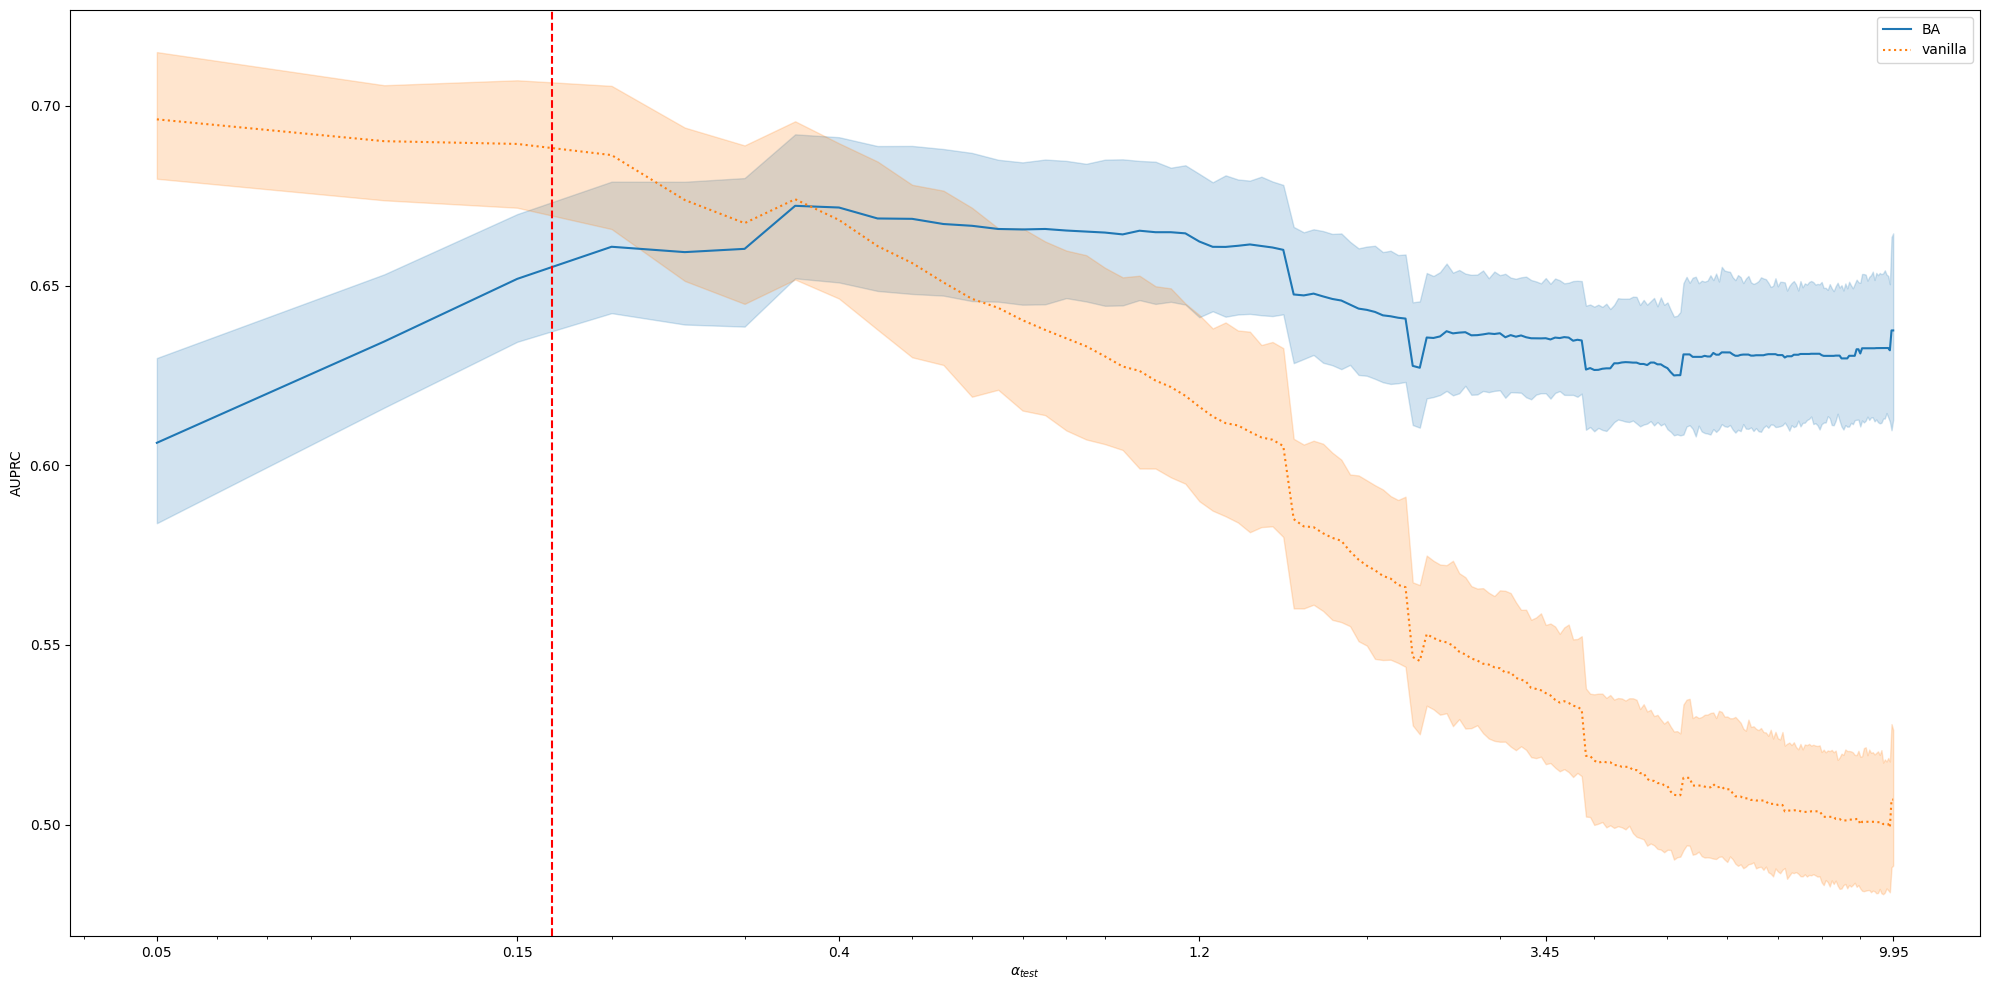

In [12]:
# better version for save
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel)

g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA")
g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", linestyle='dotted')
g_results.set(xscale="log")

ax.axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
g_results.set(xticks=sample_count)
g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
fname

In [ ]:
# better version for save
xlabel = "alpha_test"
# xlabel = "distance_EMD"

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel)

g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA", style="C_y")
g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", linestyle='dotted', style="C_y")
g_results.set(xscale="log")

ax.axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
g_results.set(xticks=sample_count)
g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
# Single Alpha Train: better version for save
xlabel = "alpha_test"

C_y = df['C_y'].unique()



fig, ax = plt.subplots(math.ceil(len(C_y)/3),3, figsize=(20,16), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(C_y):
    _df = df[df['C_y'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$C_y$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    

plt.tight_layout()


In [ ]:
1/1.125

## Comparison Plot for Vanilla LR vs Backdoor adjusted LR

In [ ]:
fname

In [ ]:
df.columns

In [ ]:
df.alpha_train.unique()

In [ ]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)
_df['C_y'] = _df['C_y'].round(2)

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])

        for i in range(2):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
            ax[i].set_ylim(0.6, 1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
## Target for One setting

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# _df = _df.query("alpha_train.isin([3,0.3333])")
# _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")

_df = _df.query("alpha_train.isin([4, 0.25])")
tmp = _df.groupby("C_y").size().reset_index()

In [ ]:
tmp

In [ ]:
## Target for One setting

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# _df = _df.query("alpha_train.isin([3,0.3333])")
# _df = _df[np.round(_df['C_y'],3).isin([ 0.25, 0.34, 0.51])]

# _df = _df.query("alpha_train.isin([6,0.1667])")
# _df = _df[np.round(_df['C_y'],3).isin([ 0.225, 0.325, 0.4])]


# _df = _df.query("alpha_train.isin([2,0.5])")
# _df = _df[np.round(_df['C_y'],3).isin([0.155,  0.25, 0.36, 0.405, 0.5, 0.6])]

_df = _df.query("alpha_train.isin([4,0.25])")
_df = _df[np.round(_df['C_y'],3).isin([0.155,  0.25, 0.36, 0.405, 0.5, 0.6])]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,2, figsize=(18,7), sharex=True)

        _df_plt = _df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ]
        # _df_plt = _df_plt.query("C_y.isin([ 0.16, 0.48, 0.72])")
        
        sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])

        for i in range(2):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.7,1)
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
## Target for One setting -- no more reciprocal

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

_df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(18,7))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', ax=ax[1])

    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].title.set_text("alpha_train: "  + str(alpha_train))
        ax[i].set_ylim(0.7,1)

    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

In [ ]:
_df

In [ ]:
## Target for One setting -- no more reciprocal
## Plotting: save coef
## SAVE!!! plot


_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

if dataset_name == 'HateSpeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.5,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "SHAC":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = get_coefLog10(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef[0]:.3f}", color=color)
        
    

# plt.show()
plt.savefig(f"{fname}.png", dpi=600)
plt.close()

In [ ]:
## Target for One setting -- no more reciprocal
## Plotting: save coef
## NO SAVE, Only One C_y


_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

if dataset_name == 'HateSpeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.5,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.48])")
    ylim = 0.8,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]




for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    # fig, ax = plt.subplots(1,2, figsize=(10,4))
    fig, ax0 = plt.subplots(1,1, figsize=(5,4))
    fig, ax1 = plt.subplots(1,1, figsize=(5,4))
    ax = [ax0, ax1]

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax0)
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax1)
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    ## Shade...
#     l1 = ax0.lines[0]

#     # Get the xy data from the lines so that we can shade
#     x1 = l1.get_xydata()[:,0]
#     y1 = l1.get_xydata()[:,1]
    
#     ax0.fill_between(x1,y1, hatch="/", facecolor="none", edgecolor="gray", linewidth=0.0)
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        # ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].get_legend().set_visible(False)
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "SHAC":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = get_coefLog10(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef[0]:.3f}", color=color)
        
    

plt.show()
# plt.savefig(f"{fname}.png", dpi=600)
plt.close()

In [ ]:
fname

In [ ]:
df.alpha_train.unique()

In [ ]:
pd.set_option('display.max_rows', 500)

print(df.groupby(['C_y', 'alpha_train', ]).size())

In [ ]:
## Target for One setting -- For Bigger Ones!!!
## Plotting: save coef
## SAVE!!! plot

a_train = [3]

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query(f"alpha_train.isin({a_train})")

if dataset_name == 'HateSpeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    # _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.4,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "SHAC":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = (x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef:.3f}", color=color)
        
    

# plt.show()
outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
plt.savefig(outname, dpi=600)
plt.close()

In [ ]:
outname

In [ ]:
_df_plt.columns

In [ ]:
_df_plt.p_mix_z0.unique()

In [ ]:
_df_plt.alpha_test.describe()

In [ ]:
max(_df_plt.alpha_test)

In [ ]:
fname

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

In [ ]:
list(sorted(_df.C_y.unique()))

In [ ]:

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

_df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")




_df_plt = _df[(_df['alpha_train'] == alpha_train)]
_df_plt = _df_plt.query("C_y.isin([0.72])")

X = _df_plt['alpha_test']
X = np.log(X)
X = sm.add_constant(X)
Y = _df_plt['auprc_logistic_confounder']


In [ ]:
lr_fit = sm.OLS(Y, X)
results = lr_fit.fit()
print(results.summary())

In [ ]:
results.params

In [ ]:
results.params['alpha_test']

## Combine All Alpha Train for ReSampling

In [ ]:
fname

In [ ]:
tmp = df.groupby("C_y").size().reset_index()

In [ ]:
tmp[tmp.iloc[:,1]>100]

In [ ]:
df['C_y'].unique()

In [ ]:
df['p_mix_z1'].unique()

In [ ]:
df['p_pos_test'].unique()

In [ ]:
## One Figure: combine

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(2)
_df = _df.query("C_y in [0.1,  0.3,0.4,0.5,0.7, 0.9]")
fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0]) 
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1])

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1 (0.2/0.2)")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

## Augmentation: mixup - AugUp

In [ ]:
fname

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df['Cy_train'] = np.max(df[['p_pos_train_z0','p_pos_train_z1']], axis=1)

In [ ]:
sum(df['Cy_train'] != df['C_y_train'])

In [ ]:
sum(~np.isclose(df['Cy_train'], df['C_y_train']))

In [ ]:
tmp = df.groupby("C_y").size().reset_index()

In [ ]:
tmp[tmp.iloc[:,1]>100]

In [ ]:
df['C_y'].unique()

In [ ]:
df['Cy_train'].unique()

In [ ]:
df['p_mix_z1'].unique()

In [ ]:
df['p_pos_test'].unique()

In [ ]:
## One Figure for each row, row by Cy_train levels

_df = df.copy()
# _df['alpha_train'] = _df['alpha_train'].round(4)

for cy_train in sorted(set(_df['Cy_train'])):

    fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

    for i in range(2):
        ax[i].set_xscale('log')
        # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        ax[i].title.set_text("Cy_train: " + str(cy_train))


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

In [ ]:
_df.groupby(['Cy_train'], as_index=False).size().sort_values("size")

In [ ]:
_df[np.isclose(_df['Cy_train'], 0.6) ].groupby(['C_y'], as_index=False).size().sort_values('size')

In [ ]:
cy_train

In [ ]:
## An example of above

_df = deepcopy(df)
# _df['alpha_train'] = _df['alpha_train'].round(4)

cy_train = 0.6
_df['C_y'] = _df['C_y'].round(2)
_df = _df.query("C_y in [0.54, 0.42]")

fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("Cy_train: " + str(cy_train))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless Cy_train levels
# no contraint on Cy_train and C_y

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(2)

cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


# _df = _df.query("C_y in [0.1,  0.3,0.4,0.5,0.7, 0.8]")
fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            )
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless C_y levels
# Force C_y == Cy_train

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(3)
_df['Cy_train'] = _df['Cy_train'].round(3)
_df = _df.query("Cy_train == C_y")
_df = _df[np.isclose(_df['C_y'],0.2)]

# _df['C_y'] = pd.Categorical(_df['C_y'])
cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            )
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1.02))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

## Augmentation: mixup Fixed Aug Frequency

In [ ]:
fname

In [ ]:
df['Cy_train'] = np.max(df[['p_pos_train_z0','p_pos_train_z1']], axis=1)

In [ ]:
df.columns

In [ ]:
df.groupby(['alpha_train']).size()

In [ ]:
df['C_y'].unique()

In [ ]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = round(_df['alpha_train'], 4)
# _df = _df.query("C_y == C_y_tra in")
# _df = _df.query("alpha_train == 3.")
# _df['alpha_train'] = _df['alpha_train'].round(4)

for cy_train in sorted(set(_df['Cy_train'])):

    fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
    sns.lineplot(data=_df[(_df['Cy_train'] == cy_train) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

    for i in range(2):
        ax[i].set_xscale('log')
        # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        ax[i].title.set_text("C_y_train: " + str(cy_train))


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

In [ ]:
## An example of above

_df = deepcopy(df)
# _df['alpha_train'] = _df['alpha_train'].round(4)

cy_train = 0.6
_df['C_y'] = _df['C_y'].round(2)
_df = _df.query("C_y in [0.54, 0.42]")

fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
sns.lineplot(data=_df[np.isclose(_df['Cy_train'], 0.6) ],x='alpha_test',y='auprc_logistic_confounder', hue='C_y', ax=ax[1])

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("Cy_train: " + str(cy_train))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless Cy_train levels
# no contraint on Cy_train and C_y

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(1)

cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


# _df = _df.query("C_y in [0.1,  0.3,0.4,0.5,0.7, 0.8]")
fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            )
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

In [ ]:
## One Figure: combine, regardless C_y levels
# Force C_y == Cy_train

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(3)
_df['Cy_train'] = _df['Cy_train'].round(3)
_df = _df.query("Cy_train == C_y")

# _df['C_y'] = pd.Categorical(_df['C_y'])
cy_levels = _df['C_y'].nunique()
my_palette = sns.color_palette("crest", cy_levels)


fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)

sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_vanilla',
             # hue="p_mix_z1",
             hue='C_y',
             ax=ax[0],
             palette=my_palette,
            ) 
sns.lineplot(data=_df,x='alpha_test',y='auprc_logistic_confounder', 
             # hue="p_mix_z1", 
             hue='C_y',
             ax=ax[1],
             palette=my_palette,
            )

for i in range(2):
    ax[i].set_xscale('log')
    # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    # ax[i].axvline(reciprocal, color="red", linestyle='solid')
    ax[i].title.set_text("alpha_train: " + "1")
    # ax[i].set(ylim=(0.6, 1))


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))
plt.show()

## Three Plots

In [ ]:
fname

In [ ]:
_df.alpha_train.unique()

In [ ]:
_df.C_y.unique()

In [ ]:
_df.query("alpha_train == 3.0").alpha_test.unique()

In [ ]:
pd.set_option('display.max_rows', None)
_df.groupby("alpha_test").size()

In [ ]:
"""
auprc_logistic_confounder
auprc_logistic_known_source
auprc_logistic_noPermute
"""

In [ ]:
## One Figure for each row

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,3, figsize=(25,7), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_noPermute', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_known_source', style='alpha_train', hue='C_y', ax=ax[2])

        for i in range(3):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
round(3.00,1)

## Importance Weighting: Four Plots

In [ ]:
fname

In [ ]:
df.columns

In [ ]:
df['alpha_test']

In [ ]:
# df[['auprc_logistic_vanilla','auprc_logistic_confounder', 'auprc_logistic_IW','auprc_logistic_naiveLossBalance']]
df[['auprc_logistic_vanilla','auprc_logistic_confounder', 'auprc_logistic_IW']]

In [ ]:
df['C_y'].unique()

In [ ]:
df['C_y_test'].unique()

In [ ]:
# _df = deepcopy(df)
# _df['alpha_train'] = _df['alpha_train'].round(4)
# _df['C_y'] = _df['C_y'].round(2)

In [ ]:
## One Figure for each row
## AUPRC

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(2)
# _df = _df[_df['C_y'].isin(list(np.arange(0.1,1,0.1)))]
# _df = _df[_df['C_y']==0.5]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,4, figsize=(18,3), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[1])
        # sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_naiveLossBalance', style='alpha_train', 
        #              hue='C_y_test',
        #              ax=ax[2])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[3])
        

        for i in range(4):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.8,1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
## One Figure for each row
## AUROC

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(2)
# _df = _df[_df['C_y'].isin(list(np.arange(0.1,1,0.1)))]
# _df = _df[_df['C_y']==0.5]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,4, figsize=(18,3), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auroc_logistic_vanilla', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auroc_logistic_confounder', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[1])
        # sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auroc_logistic_naiveLossBalance', style='alpha_train', 
        #              hue='C_y_test',
        #              ax=ax[2])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auroc_logistic_IW', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[3])
        

        for i in range(4):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.8,1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
sum(df['C_y_test'] != df['C_y'])

In [ ]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(2)
# _df = _df[_df['C_y_test'].isin(list(np.arange(0.1,1,0.2).round(2)))]
_df = _df[np.isclose(_df['C_y_test'],0.5)]

# _df = _df[_df['C_y']==0.5]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,4, figsize=(18,3), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[1])
        # sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_naiveLossBalance', style='alpha_train', 
        #              hue='C_y_test',
        #              ax=ax[2])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[3])

        for i in range(4):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.8, 1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
df.columns

In [ ]:
## One Figure for each row

_df = deepcopy(df)
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(2)
# _df = _df[_df['C_y_test'].isin(list(np.arange(0.1,1,0.2).round(2)))]
_df = _df[np.isclose(_df['C_y_test'],0.5)]

# _df = _df[_df['C_y']==0.5]

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,3, figsize=(14,3), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='f1_vanilla', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='f1_confounder', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[1])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='f1_IW', style='alpha_train', 
                     hue='C_y_test',
                     ax=ax[2])


        for i in range(3):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.8, 1.02)
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
# from sklearn.preprocessing import minmax_scale

# colors_ = range(df_summary['cy'].nunique())
# discrete_colors = sample_colorscale('Bluered', minmax_scale(colors_))


In [ ]:
tmp = df.groupby('C_y_test', as_index=False).size()
tmp.sort_values("size", ascending=False)

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)



# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
#              hue='C_y',
#              ax=ax[0])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
#              hue='C_y',
#              ax=ax[1])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
#              hue='C_y',
#              ax=ax[2])

fig = px.scatter_3d(_df, x='alpha_train', y='alpha_test', z='auprc_logistic_vanilla',
              color='auprc_logistic_vanilla', 
                    # size='petal_length', size_max=18,
              # symbol='species', 
                    opacity=0.7)

fig = px.scatter_3d(_df, x='C_y', y='C_y_test', z='auprc_logistic_vanilla',
              color='auprc_logistic_vanilla', 
                    # size='petal_length', size_max=18,
              # symbol='species', 
                    opacity=0.7)

# fig = go.Figure(data=[go.Surface(z=_df['auprc_logistic_vanilla'], x=_df['C_y'], y=_df['C_y_test'])])
# fig = go.Figure(data=[go.Surface(z=z, x=x, y=y)])
# fig.update_layout(title='Wwwwt?', autosize=True,
#                   width=500, height=500,
#                   # margin=dict(l=65, r=50, b=65, t=90)
#                  )
fig.show()

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)



# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', 
#              hue='C_y',
#              ax=ax[0])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', 
#              hue='C_y',
#              ax=ax[1])
# sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_IW', style='alpha_train', 
#              hue='C_y',
#              ax=ax[2])

# fig = px.scatter_3d(_df, x='alpha_train', y='alpha_test', z='auprc_logistic_vanilla',
#               color='auprc_logistic_vanilla', 
#                     # size='petal_length', size_max=18,
#               # symbol='species', 
#                     opacity=0.7)

fig = px.scatter_3d(_df, x='C_y', y='C_y_test', z='auprc_logistic_IW',
              color='auprc_logistic_vanilla', 
                    # size='petal_length', size_max=18,
              # symbol='species', 
                    opacity=0.7)

# fig = go.Figure(data=[go.Surface(z=_df['auprc_logistic_vanilla'], x=_df['C_y'], y=_df['C_y_test'])])
# fig = go.Figure(data=[go.Surface(z=z, x=x, y=y)])
# fig.update_layout(title='Wwwwt?', autosize=True,
#                   width=500, height=500,
#                   # margin=dict(l=65, r=50, b=65, t=90)
#                  )
fig.show()

In [ ]:

fig = px.scatter(df_summary, x="predMidpoint", y="coef", 
                 error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 error_y="coef_lowerdiff", error_y_minus="coef_upperdiff",
                 color="cy", facet_col="loraR", facet_row="model_size",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 color_continuous_scale=px.colors.sequential.Emrld,
                 # color_discrete_sequence=discrete_colors,
                 width=1400, height=1000,
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
              
              
fig.show()



In [ ]:
y_name = "auprc_weightsEdited"
x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.8,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]



n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate(["auprc_weightsEdited"]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
_df = df.copy()
_df['C_y1'] = np.floor(_df['C_y']*10)/10
_df['C_y'] = _df['C_y'].round(2)

In [ ]:
dfgrp = _df.groupby(['C_y1', 'C_y'], as_index=False).size()
dfgrp = dfgrp.sort_values("size", ascending=False)
dfgrp = dfgrp.groupby("C_y1", as_index=False).head(1)

In [ ]:
dfgrp

In [ ]:
y_name = "auprc_weightsEdited"
x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.8,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate(["auprc_weightsEdited"]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

## Predict for Z

In [ ]:
sns.set_theme(rc={"figure.dpi": 150})
sns.set_context("paper")


In [ ]:
fname

In [ ]:
[x for x in df.columns if x.startswith("auprc")]

In [ ]:
# df[['auprc_logistic_vanilla','auprc_logistic_confounder', 'auprc_logistic_IW','auprc_logistic_naiveLossBalance']]
df[['auprc_vanilla','auprc_confound', 'auprc_IW', 'auprc_EM', 'auprc_TrueZ', 'C_z', 'p_z_simpleInfer_1','p_z_pred_IW_1', 'p_z_pred_EM_1']]

In [ ]:
g = sns.pairplot(df[['C_z', 'p_z_simpleInfer_1','p_z_pred_IW_1', 'p_z_pred_EM_1']])
for ax in g.axes.ravel():
    ax.set_xlim((-0.02,1.02))
    ax.set_ylim((-0.02,1.02))

In [ ]:
sns.pairplot(df[['auprc_vanilla','auprc_confound', 'auprc_IW', 'auprc_EM', 'auprc_TrueZ']])

In [ ]:
sns.pairplot(df[['f1_vanilla','f1_confound', 'f1_IW', 'f1_EM', 'f1_TrueZ']])

In [ ]:
df.groupby('C_y', as_index=False).size().sort_values('size', ascending=False)

In [ ]:
## One Figure for each row
## AUPRC
alpha_train = 5

_df = deepcopy(df)
# _df = _df[ (_df['p_z_pred_1'] <= 1) & (_df['p_z_pred_1'] >= 0)]
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(1)
# _df = _df[_df['C_y'].isin(list(np.arange(0.1,1,0.1)))]
_df = _df[_df['C_y']==0.4]




for cz in sorted(set(_df['C_z'])):

    #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    

    y_ls = ['f1_vanilla', 'f1_confound', 'f1_IW', 'f1_EM', 'f1_TrueZ']
    # y_ls = ['f1_vanilla_df0', 'f1_confound_df0', 'f1_IW_df0', 'f1_EM_df0', 'f1_TrueZ_df0']
    # y_ls = ['f1_vanilla_df1', 'f1_confound_df1', 'f1_IW_df1', 'f1_EM_df1', 'f1_TrueZ_df1']

    # y_ls = ['calibration_vanilla', 'calibration_confound', 'calibration_IW', 'calibration_EM', 'calibration_TrueZ']
    # y_ls = ['calibration_vanilla_df0', 'calibration_confound_df0', 'calibration_IW_df0', 'calibration_EM_df0', 'calibration_TrueZ_df0']
    # y_ls = ['calibration_vanilla_df1', 'calibration_confound_df1', 'calibration_IW_df1', 'calibration_EM_df1', 'calibration_TrueZ_df1']

    # y_ls = ['auprc_vanilla', 'auprc_confound', 'auprc_IW', 'auprc_EM', 'auprc_TrueZ']
    # y_ls = ['auprc_vanilla_df0', 'auprc_confound_df0', 'auprc_IW_df0', 'auprc_EM_df0', 'auprc_TrueZ_df0']
    # y_ls = ['auprc_vanilla_df1', 'auprc_confound_df1', 'auprc_IW_df1', 'auprc_EM_df1', 'auprc_TrueZ_df1']
    

    fig, ax = plt.subplots(1,len(y_ls), figsize=(18,3), sharey=True)
    for i,_y in enumerate(y_ls):
        sns.lineplot(data=_df[(_df['C_z'] == cz) ], x='alpha_test', y=_y, #style='alpha_train', 
                 hue='C_y_test',
                 ax=ax[i])
        
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        # ax[i].axhline(1, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        # ax[i].title.set_text(_y + " alpha_train: " + str(alpha_train) + " C_z: " + str(cz))
        ax[i].title.set_text(_y + " " + "C_z: " + f"{cz:.2f}")
        ax[i].set_ylabel(_y.split("_")[0])

        # ax[i].set_ylim(0.8,1.02)


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

        



In [ ]:
## One Figure for each row
## AUPRC
alpha_train = 5

_df = deepcopy(df)
# _df = _df[ (_df['p_z_pred_1'] <= 1) & (_df['p_z_pred_1'] >= 0)]
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y_test'] = _df['C_y_test'].round(1)
# _df = _df[_df['C_y'].isin(list(np.arange(0.1,1,0.1)))]
_df = _df[_df['C_z']==0.5]




for cy in sorted(set(_df['C_y_test'])):

    #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    

    # y_ls = ['f1_vanilla', 'f1_confound', 'f1_IW', 'f1_EM', 'f1_TrueZ']
    # y_ls = ['f1_vanilla_df0', 'f1_confound_df0', 'f1_IW_df0', 'f1_EM_df0', 'f1_TrueZ_df0']
    # y_ls = ['f1_vanilla_df1', 'f1_confound_df1', 'f1_IW_df1', 'f1_EM_df1', 'f1_TrueZ_df1']

    # y_ls = ['calibration_vanilla', 'calibration_confound', 'calibration_IW', 'calibration_EM', 'calibration_TrueZ']
    # y_ls = ['calibration_vanilla_df0', 'calibration_confound_df0', 'calibration_IW_df0', 'calibration_EM_df0', 'calibration_TrueZ_df0']
    # y_ls = ['calibration_vanilla_df1', 'calibration_confound_df1', 'calibration_IW_df1', 'calibration_EM_df1', 'calibration_TrueZ_df1']

    y_ls = ['auprc_vanilla', 'auprc_confound', 'auprc_IW', 'auprc_EM', 'auprc_TrueZ']
    # y_ls = ['auprc_vanilla_df0', 'auprc_confound_df0', 'auprc_IW_df0', 'auprc_EM_df0', 'auprc_TrueZ_df0']
    # y_ls = ['auprc_vanilla_df1', 'auprc_confound_df1', 'auprc_IW_df1', 'auprc_EM_df1', 'auprc_TrueZ_df1']
    

    fig, ax = plt.subplots(1,len(y_ls), figsize=(18,3), sharey=True)
    for i,_y in enumerate(y_ls):
        sns.lineplot(data=_df[(_df['C_y_test'] == cy) ], x='alpha_test', y=_y, #style='alpha_train', 
                 # hue='C_y_test',
                 ax=ax[i])
        
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        # ax[i].axhline(1, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        # ax[i].title.set_text(_y + " alpha_train: " + str(alpha_train) + " C_z: " + str(cz))
        ax[i].title.set_text(_y + " " + "C_y_test: " + f"{cy:.2f}")
        ax[i].set_ylabel(_y.split("_")[0])

        # ax[i].set_ylim(0.8,1.02)


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

        



## Lora Fine-tuning Set One Plot

In [ ]:
fname

In [ ]:
df.columns

In [ ]:
# sum(df['C_y'] != df["C_y_test"])

In [ ]:
_df = df.copy()
_df['C_y1'] = np.floor(_df['C_y']*10)/10
_df['C_y'] = _df['C_y'].round(2)

In [ ]:
dfgrp = _df.groupby(['C_y1', 'C_y'], as_index=False).size()
dfgrp = dfgrp.sort_values("size", ascending=False)
dfgrp = dfgrp.groupby("C_y1", as_index=False).head(1)

In [ ]:
dfgrp

In [ ]:
y_name = "auprc_weightsEdited"
# y_name = "auroc_weightsEdited"
# y_name = "f1_weightsEdited"

x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


# _df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()
_df_plt = _df[_df['C_y'].isin([0.3,0.5,0.7])].copy()
# _df_plt = _df.copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    ylim = 0.8,1.02
    # ylim = None
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
# ax.set_ylabel(y_name)
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate([y_name]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
# y_name = "auprc_weightsEdited"
y_name = "auroc_weightsEdited"
# y_name = "f1_weightsEdited"

x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.7,1.02
    # ylim=None
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
# ax.set_ylabel("AUPRC")
ax.set_ylabel(y_name)
# ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))


x=np.quantile(sorted(_df_plt[x_name]),1)

if dataset_name == "SHAC":
    y=np.quantile(sorted(_df_plt[y_name]),0.5)
    y=np.mean(sorted(_df_plt[y_name]))
elif dataset_name == 'HateSpeech':
    y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    reg = get_regression(x=_df_plt[x_name], y=_df_plt[y_name])
elif x_name in ["alpha_test"]:
    reg = get_coefLog10(x=_df_plt[x_name], y=_df_plt[y_name])



ax.text(x,y, f"coef={coef:.3f}", color=color)


plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
_df.columns

In [ ]:
y_name = "f1_weightsEdited"
x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
# x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.6,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel(f"{y_name}")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate(["auprc_weightsEdited"]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train", "distance_EMD"]:
            reg = get_regression(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        elif x_name in ["alpha_test"]:
            reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
            pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
            pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
# def conditionWass1d(distrListA, distrListB, conditionListZ):
#     ret = 0
#     for distrA, distrB, condZ in zip(distrListA, distrListB, conditionListZ):
        
#         ret_inner = scipy.stats.wasserstein_distance(np.arange(2), np.arange(2), distrA,distrB)
#         ret_condition = ret_inner * condZ
        
#         ret += ret_condition
        
#     return ret
    

# p_pos_train_z0 = 0.2
# p_pos_train_z1 = 0.2
# p_mix_z0 = 0.5
# p_mix_z1 = 1 - p_mix_z0


# distriListA = [[p_pos_train_z0, 1-p_pos_train_z0],[p_pos_train_z1, 1-p_pos_train_z1]]
# conditionListC = [p_mix_z0, p_mix_z1]


# df['distance_KL_Train_Test'] = df.apply(lambda x: conditionKL(
#     distriListA,
#     [[x['p_pos_test_z0'], 1-x['p_pos_test_z0']],[x['p_pos_test_z1'], 1-x['p_pos_test_z1']]],
#     conditionListC
#                                                    ),
#                                               axis=1
#                                              )


# df['distance_KL_Test_Train'] = df.apply(lambda x: conditionKL(
#     [[x['p_pos_test_z0'], 1-x['p_pos_test_z0']],[x['p_pos_test_z1'], 1-x['p_pos_test_z1']]],
#     distriListA,
#     [x['p_mix_z0'], x['p_mix_z1']]
#                                                    ),
#                                               axis=1
#                                              )




# # df['distance_EMD'] = df.apply(lambda x: conditionWass1d(
# #     distriListA,
# #     [[x['p_pos_test_z0'], 1-x['p_pos_test_z0']],[x['p_pos_test_z1'], 1-x['p_pos_test_z1']]],
# #     conditionListC
# #                                                    ),
# #                                               axis=1
# #                                              )



y_name = "auprc_weightsEdited"
# x_name = "alpha_test"
# x_name = "distance_KL_Train_Test"
x_name = "distance_KL_Test_Train"
# x_name = "distance_EMD"


_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.8,1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 3
fig, ax = plt.subplots(5,2, figsize=(18,20))
ax = ax.ravel()

for i,cy in enumerate(_df_plt['C_y'].unique()):
    _df_tmp = _df_plt[_df_plt['C_y'] == cy]
    sns.lineplot(data=_df_tmp, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax[i])

if x_name in ["distance_KL_Train_Test", "distance_KL_Test_Train"]:
    ylim = None
    xlim = None
    xlab = x_name
    
elif x_name in ["alpha_test"]:
    ax.set_xscale('log')
    xlab = r"$\alpha_{test}$"
    
    
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()

In [ ]:
# x_name = "distance_KL_Train_Test"
# x_name = "distance_EMD"

sns.lineplot(data=df, x="alpha_test", y="distance_KL_Train_Test")

In [ ]:
# x_name = "distance_KL_Train_Test"
# x_name = "distance_EMD"

sns.lineplot(data=df, x="alpha_test", y="distance_KL_Test_Train")

In [ ]:
# x_name = "distance_KL_Train_Test"
# x_name = "distance_EMD"

sns.lineplot(data=df, x="alpha_test", y="distance_EMD")

In [ ]:
## Target for One setting -- For Bigger Ones!!!
## Plotting: save coef
## SAVE!!! plot

a_train = [3]

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query(f"alpha_train.isin({a_train})")

if dataset_name == 'HateSpeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    # _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.4,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "SHAC":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = (x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef:.3f}", color=color)
        
    

# plt.show()
outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
plt.savefig(outname, dpi=600)
plt.close()

## Only One Plot

In [ ]:
fname

In [ ]:
_df = df.copy()
_df['C_y1'] = np.floor(_df['C_y']*10)/10
_df['C_y'] = _df['C_y'].round(2)

dfgrp = _df.groupby(['C_y1', 'C_y'], as_index=False).size()
dfgrp = dfgrp.sort_values("size", ascending=False)
dfgrp = dfgrp.groupby("C_y1", as_index=False).head(1)


y_name = "auprc_logistic_vanilla"
x_name = "alpha_test"

_df_plt = _df[_df['C_y'].isin(dfgrp['C_y'])].copy()

cy_levels = _df_plt['C_y'].nunique()


my_palette = sns.color_palette("crest", cy_levels)

if dataset_name == 'HateSpeech':
    
    ylim = 0.2,1.05
    # ylim = 0,1.05
    # xlim = 0.009,400
    xlim = 0.009,150
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'SHAC':
    # _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    # ylim = 0.4,1.02
    # ylim = 0.6,1.02
    ylim = 0.7,1.02
    ylim = 0.4, 1.02
    xlim = 0.07,40
    loc_legend = "lower left"
    # loc_legend = "best"
    loc_coef_y = 0 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

    

n_cols = 1
fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

sns.lineplot(data=_df_plt, x=x_name, y=y_name, hue='C_y', palette=my_palette, ax=ax)


ax.set_xscale('log')
xlab = r"$\alpha_{test}$"
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(xlab)
ax.set_ylabel("AUPRC")
ax.legend(loc=loc_legend, title=r'$C_y$')

# ax.axvline(alpha_train, color="red", linestyle='dashed')
# ax.axvline(reciprocal, color="red", linestyle='solid')
# ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
# ax.title.set_text(Path(fname).name)


# plt.axvline(alpha_train,color='black')
# plt.axvline(reciprocal, color='beige')
# plt.title('alpha_train: ' + str(alpha_train))

pred_ls = []
coef_ls = []
cy_ls = []
for item, color in zip(_df_plt.groupby('C_y'), my_palette):
    #item[1] is a grouped data frame
    for iy, ylabel in enumerate([y_name]):
        
        

        x=np.quantile(sorted(item[1][x_name]),1)
        

        if dataset_name == "SHAC":
            y=np.quantile(sorted(item[1][item[1][x_name] == x][ylabel]),0.5)
            y=np.mean(sorted(item[1][item[1][x_name] == x][ylabel]))
        elif dataset_name == 'HateSpeech':
            y=sorted(item[1][item[1][x_name] == x][ylabel])[loc_coef_y]

       
        
        reg = get_coefLog10(x=list(item[1][x_name]), y=list(item[1][ylabel]))
        pred = reg[1].predict([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))])[0]
        pred_ls.append(pred)
            
        coef = reg[0]
        coef_ls.append(coef)
        cy_ls.append(item[0])
        

        ax.text(x, y, f"coef={coef:.3f}", color=color)
        
        
plt.show()
# outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
# plt.savefig(outname, dpi=600)
# plt.close()




In [ ]:
fname

In [ ]:
df.columns

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# y_name = 'auprc_lora'
y_name = "auprc_weightsEdited"
# _df = _df.query("C_y.isin([0.16, 0.3, 0.5, 0.75, 0.8])")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,n_cols, figsize=(8,7))
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y=y_name, style='alpha_train', hue='C_y', ax=ax)

        for i in range(n_cols):
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.axvline(reciprocal, color="red", linestyle='solid')
            ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [ ]:
reg[1].summary()

In [ ]:
reg[1].get_prediction([1,np.log10(np.quantile(sorted(item[1][x_name]),0.5))]).summary_frame(alpha = 0.05)

In [ ]:
## Target for one setting...
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([3, 0.3333])")

# _df = _df.query("C_y.isin([0.17, 0.46,  0.75])")
# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    
    if alpha_train >= 1 :
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],
                     x='alpha_test',
                     y='auprc_logistic_vanilla', 
                     style='alpha_train', 
                     hue='C_y',
                     # hue="C_y_cut",
                     ax=ax,
                    )

        for i in range(n_cols):
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.axvline(reciprocal, color="red", linestyle='solid')
            ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))

            ax.set_ylim(0.7,1)
        plt.show()
plt.close()

In [ ]:
_df['C_y'].unique()

In [ ]:
## Target for one setting...
## remove reciprocal

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

# _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")

# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    

    
    fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

    sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) ],
                 x='alpha_test',
                 y='auprc_logistic_vanilla', 
                 style='alpha_train', 
                 hue='C_y',
                 # hue="C_y_cut",
                 ax=ax,
                )

    for i in range(n_cols):
        ax.set_xscale('log')
        ax.axvline(alpha_train, color="red", linestyle='dashed')
        ax.title.set_text("alpha_train: " + str(alpha_train))

        ax.set_ylim(0.7,1)
    plt.show()
plt.close()

In [ ]:
## Target for one setting...
## remove reciprocal
## SAVE!!! plot

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

if dataset_name == 'HateSpeech':
    _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    ylim=0.5,1
    
    
    loc_legend = "best"
    loc_coef_x = -40
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.1, 0.5, 1,]
    
elif dataset_name == 'SHAC':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim=0.6,1
    loc_legend = "best"
    loc_coef_x = -30
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.2, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    

    
    fig, ax = plt.subplots(1,n_cols, figsize=(5,4))

    sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) ],
                 x='alpha_test',
                 y='auprc_logistic_vanilla', 
                 hue='C_y',
                 palette=palette,
                 
                 style='C_y',
                 ax=ax,
                )
    
    
    for item, color in zip(_df.groupby('C_y'), palette):        
        for ylabel in ['auprc_logistic_vanilla']:
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            coef = get_coefLog10(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))[0]

            ax.text(x, y, f"coef={coef:.3f}", color=color)
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.set_ylim(ylim)
            
            ax.legend(loc=loc_legend, title=r'$C_y$')
            ax.xaxis.set_major_formatter(ScalarFormatter())
            ax.set_xticks(xticks)

            ax.title.set_text(r"$\alpha_{train}$ = " + str(alpha_train))
            ax.set_xlabel(r"$\alpha_{test}$")
            ax.set_ylabel("AUPRC")
        

        
plt.show()    
# plt.savefig(f"{fname}.png", dpi=600)
plt.close()

In [ ]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

In [ ]:
list(sorted(_df.C_y.unique()))

In [ ]:
fname

In [ ]:
list(df.query("(alpha_train==1)")['C_y'].unique())

In [ ]:
# better version for save
xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel).copy().reset_index(drop=True)

_df['C_y'] = _df['C_y'].round(4)
_df = _df.query("C_y.isin([0.2,0.4,0.5,0.6,0.8,0.9])")

# names_auprc = ['auprc_logistic_vanilla', 'auprc_logistic_confounder']
names_auprc = ['auprc_logistic_vanilla']

_df = _df.melt(id_vars = [xlabel, "C_y"], value_vars=names_auprc, var_name="auprcName", value_name="auprc")


g_results=sns.lineplot(data=_df, x=xlabel, y='auprc', ax=ax, hue="auprcName", style="C_y")

# g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA", style="C_y")
# g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", style="C_y")
# g_results.set(xscale="log")

# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
# ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
# sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
# g_results.set(xticks=sample_count)
# g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
_df = df.copy()
_df = _df.query("alpha_train.isin([1,4, 0.25])").reset_index(drop=True)


fig, ax = plt.subplots(1,1, figsize=(8,8))

# sns.lineplot(data = _df, x='alpha_test', y='distance_KL_Train_Test', ax=ax, hue="alpha_train")
sns.lineplot(data = _df, y='alpha_test', x='distance_KL_Train_Test', ax=ax, hue="alpha_train")

ax.set_xscale("log")

In [ ]:
_df = df.copy()
_df = _df.query("alpha_train.isin([1,4, 0.25])").reset_index(drop=True)


fig, ax = plt.subplots(1,1, figsize=(8,8))

sns.lineplot(data = _df, x='alpha_test', y='distance_KL_Train_Test', ax=ax, hue="alpha_train")

ax.set_xscale("log")

In [ ]:
fname

In [ ]:
######  Saving
# better version for save
# regular x scale

xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()[1:-1]
# p_mix_z1 = df['p_mix_z1'].unique()[1:4]
p_mix_z1 = [0.3,0.5,0.6]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(15,4))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'].round(2) == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    # g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")


plt.tight_layout()

plt.savefig(f"{fname}.png", dpi=400)
plt.close()

In [ ]:
######  Saving
# better version for save
# log scale of x


xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()[1:-1]
# p_mix_z1 = df['p_mix_z1'].unique()[1:4]
p_mix_z1 = [0.3,0.5,0.6]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(15,4), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'].round(2) == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}", fontsize=16)
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    ax[idx].set_xlabel(r"$\alpha_{test}$", fontsize=16)
    ax[idx].set_ylabel("AUPRC", fontsize=16)
    
    sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    g_results.set(xticks=sample_count)
    g_results.set(xticklabels=sample_count)
    
    # ylabels = ['{:,.2f}'.format(x) for x in ax[idx].get_yticks()]
    # ax[idx].set_yticklabels(ylabels)
    
    # for SentenceBERT
    # ax[idx].set_ylim(0.81,0.95)
    
    ax[idx].xaxis.set_tick_params(labelsize=14)
    ax[idx].yaxis.set_tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(f"{fname}_logScale.png", dpi=400)
plt.close()

In [ ]:
# better version for save
# xlabel = "alpha_test"
xlabel = "distance_EMD"
# xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    # g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=f"{xlabel}", ylabel="AUPRC")
    # sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    # g_results.set(xticks=sample_count)
    # g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values("alpha_test")
    
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df0', ax=ax[idx], label="confounder-df0", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df1', ax=ax[idx], label="confounder-df1", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df0', ax=ax[idx], label="vanilla-df0", alpha=0.6,linestyle='dashed')
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df1', ax=ax[idx], label="vanilla-df1", alpha=0.6,linestyle='dashed')
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_confounder'], label="confounder")
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_vanilla'], label="vanilla")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()
plt.tight_layout()

In [ ]:
xlabel = "distance_EMD"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df0', ax=ax[idx], label="confounder-df0", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df1', ax=ax[idx], label="confounder-df1", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df0', ax=ax[idx], label="vanilla-df0", alpha=0.6,linestyle='dashed')
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df1', ax=ax[idx], label="vanilla-df1", alpha=0.6,linestyle='dashed')
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_confounder'], label="confounder")
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_vanilla'], label="vanilla")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()
plt.tight_layout()

In [ ]:
xlabel = "distance_EMD"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,10), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="confounder")
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla")
    
    ax[idx].set_xlabel(xlabel)
    ax[idx].set_ylabel("AUPRC")
    # ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()

plt.tight_layout()

In [ ]:
xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,10))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="confounder")
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla")
    
    ax[idx].set_xlabel(xlabel)
    ax[idx].set_ylabel("AUPRC")
    # ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()

plt.tight_layout()

In [ ]:
# xlabel = "distance_KL_Train_Test"
xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


In [ ]:
xlabel = "distance_KL_Train_Test"
# xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


In [ ]:
xlabel = "distance_KL_Train_Test"
# xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


## Task Vector Comparison Plot

In [782]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [809]:
# sets_ls = [6621, 3636, 566]
# alpha_train_ls = [0.2,1,5]
# sets_reduce_ls = [6621, 566]
# alpha_train_reduce_ls = [0.2, 5]
# # dataset_name = 'HateSpeech'
# dataset_name = 'CD'

sets_ls = [11063, 6114, 1152]
alpha_train_ls = [0.2, 1, 5]
sets_reduce_ls = [11063, 1152]
alpha_train_reduce_ls = [0.2, 5]
dataset_name = 'SHAC'


# modelUsed = "Llama"
modelUsed = "RoBERTa"

if modelUsed == "Llama":
    fname_base = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_edited = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"

    fname_reverse_base = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_reverse_edited = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"
elif modelUsed == "RoBERTa":
    fname_base = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_edited = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"

    fname_reverse_base = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_reverse_edited = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"



In [810]:
df_ls = []

for set_i in sets_ls:
    for nm in [fname_base, fname_edited, fname_reverse_base, fname_reverse_edited]:
        with open(nm.format(dataset_name, set_i), "rb") as f:
            df_tmp = pickle.load(file=f)
            
        df_tmp['set'] = set_i
        
        if "lambda2_0.0" in nm:
            df_tmp["lambda1_lambda2"] = "1.0-0.0"
        elif "lambda2_1.0" in nm:
            df_tmp["lambda1_lambda2"] = "1.0-1.0"
            
        if "Reverse" in nm:
            df_tmp['tv_direction'] = 'ReverseSource'
        else:
            df_tmp['tv_direction'] = 'Source'
        
        df_ls.append(df_tmp)
        del df_tmp
        
df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [811]:
### All From Source

# savefig = False
savefig = True

my_palette = sns.color_palette("colorblind", 2)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

sr = "Source"
# sr = "ReverseSource"

outname = f"../output/TaskVectorFigs/fig_NoDAAllSource_{dataset_name}_{modelUsed}_{sr}_Cz_0.5_Cy_0.5.png"

_df = deepcopy(df_eval)

_df = _df[_df['tv_direction'] == sr].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)

for i, (set_i, alpha_train) in enumerate(zip(sets_ls, alpha_train_ls)):
    df_sub = _df[_df['set'] == set_i]

    for ilambda, lambda_com in enumerate(["1.0-0.0", "1.0-1.0"]):
        
        _df_plt = df_sub[df_sub['lambda1_lambda2'] == lambda_com].copy()
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))
        
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=my_palette[ilambda], 
                     linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                    )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="black", linestyle='dashdot')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [812]:
sns.color_palette("colorblind", 3)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)]

In [813]:
### Dominance-Aware Provenance Source/ReverseSource

# savefig = False
savefig = True

my_palette = sns.color_palette("colorblind", 3)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/fig_DA_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)

if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

# plt.figure() 
fig, ax = plt.subplots(1,2,figsize=(8,4), sharey=True)

for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):

        
    df_sub = _df[_df['set'] == set_i]

    for ilambda, lambda_com in enumerate(["1.0-0.0", "1.0-1.0"]):
        c = my_palette[ilambda]
        
        if (set_i in [6621, 11063]) and (lambda_com == "1.0-1.0"):
            c = my_palette[-1]
            
        _df_plt = df_sub[df_sub['lambda1_lambda2'] == lambda_com].copy()
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))
        
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                    )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="black", linestyle='dashdot')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

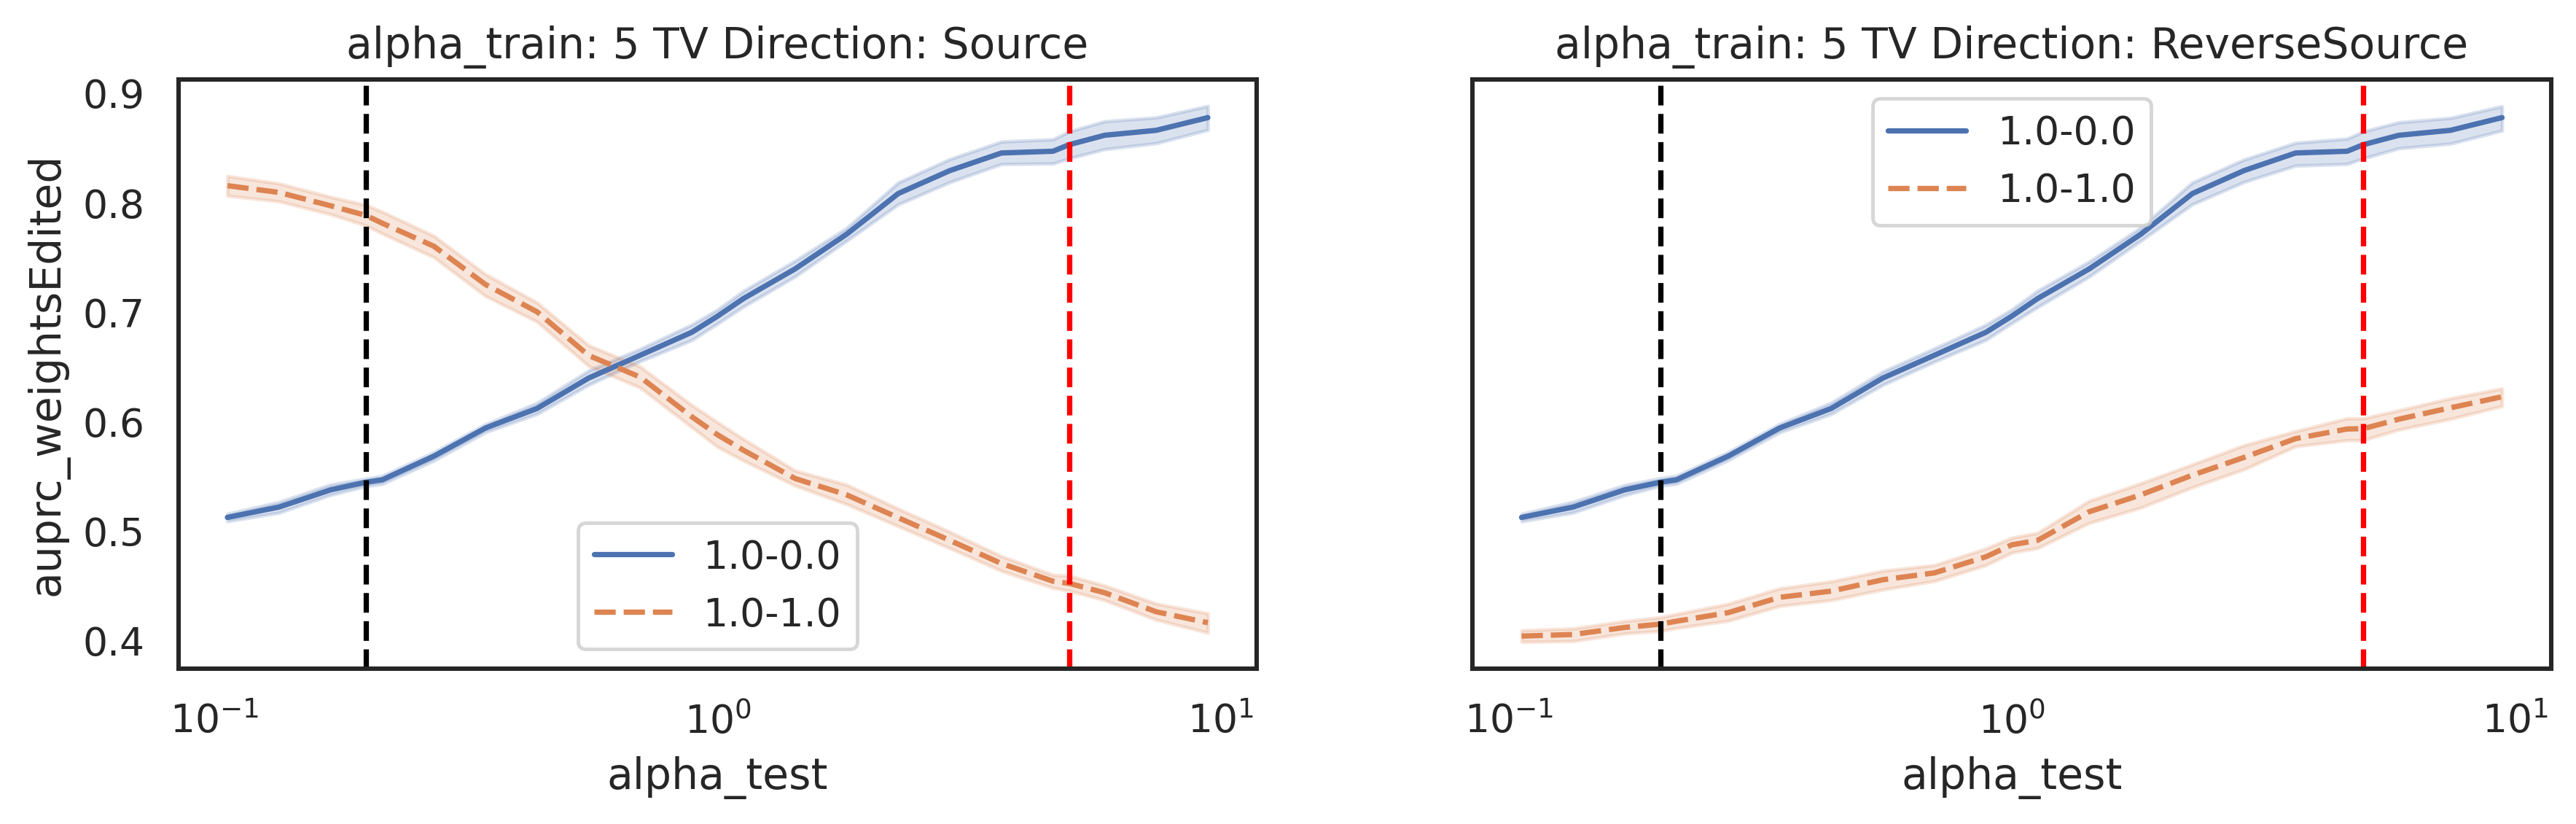

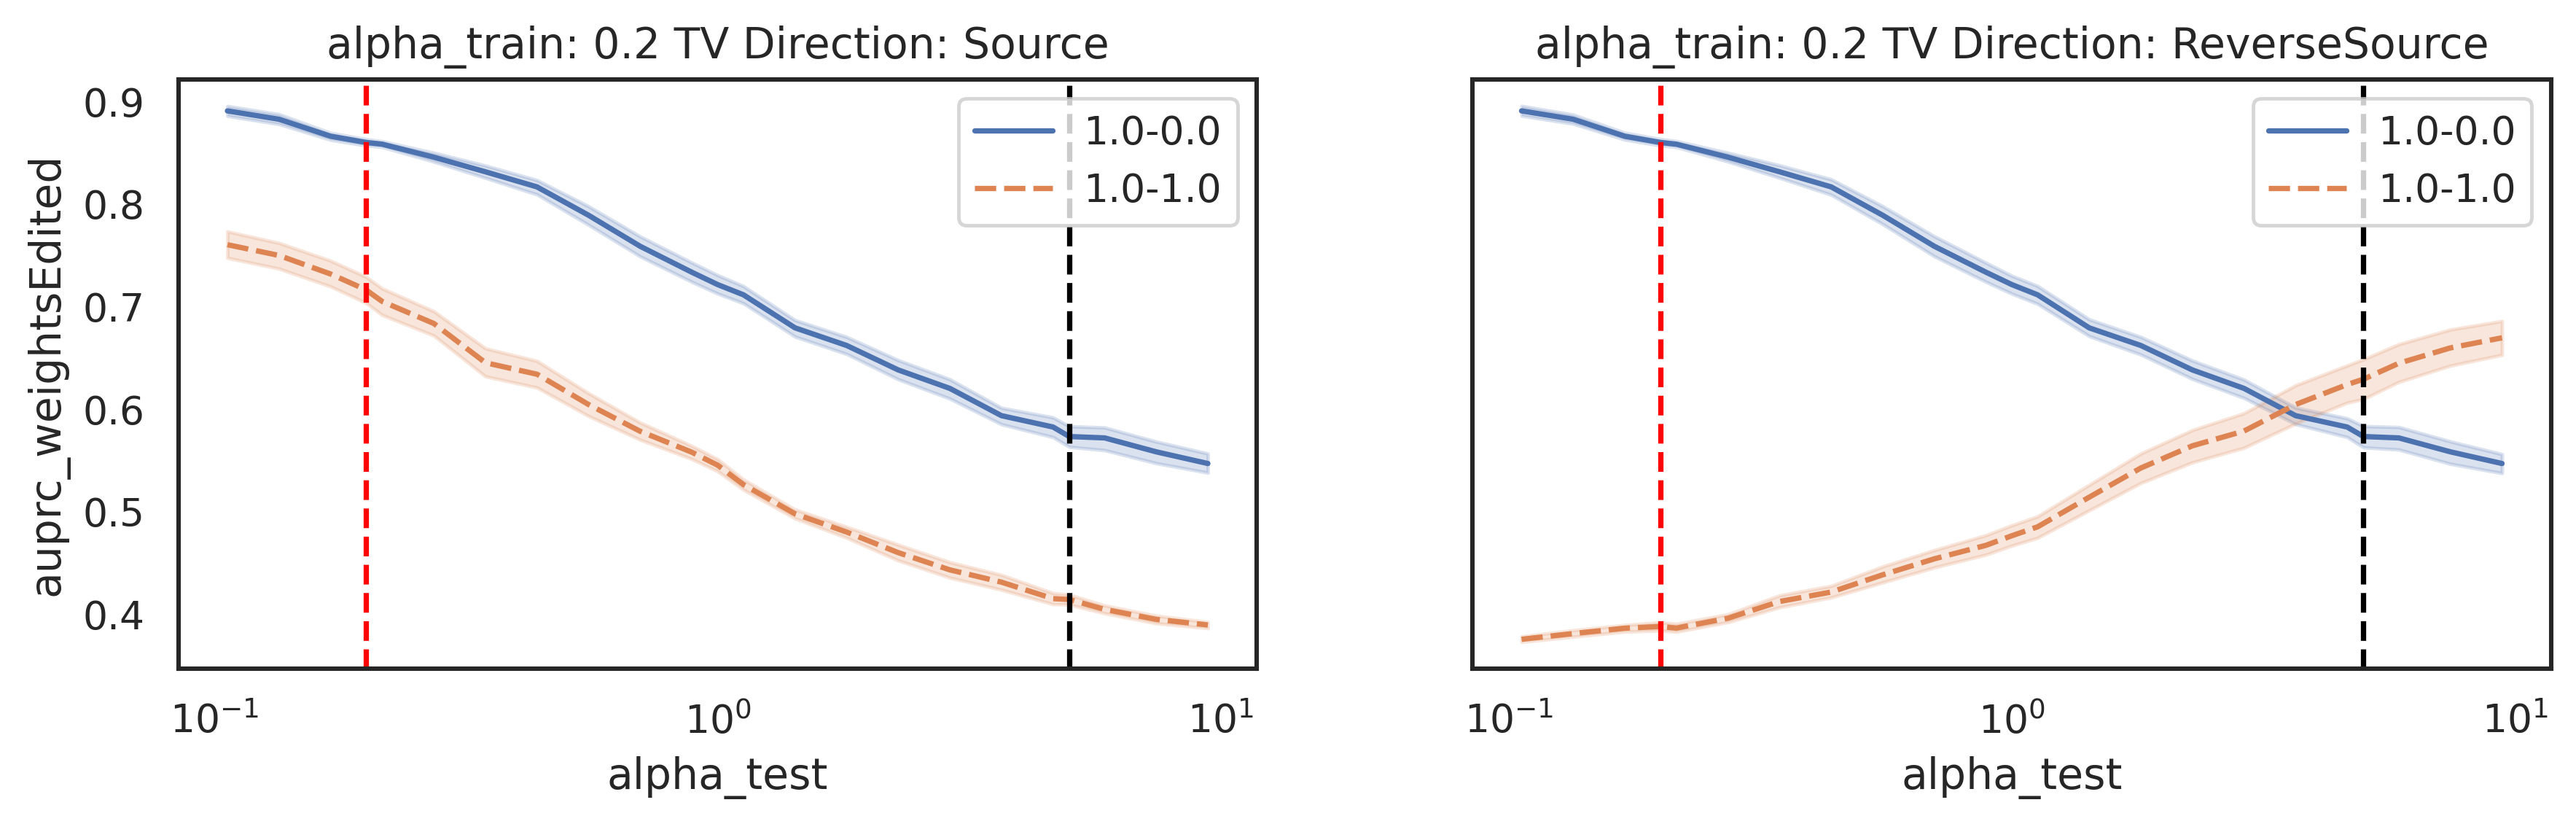

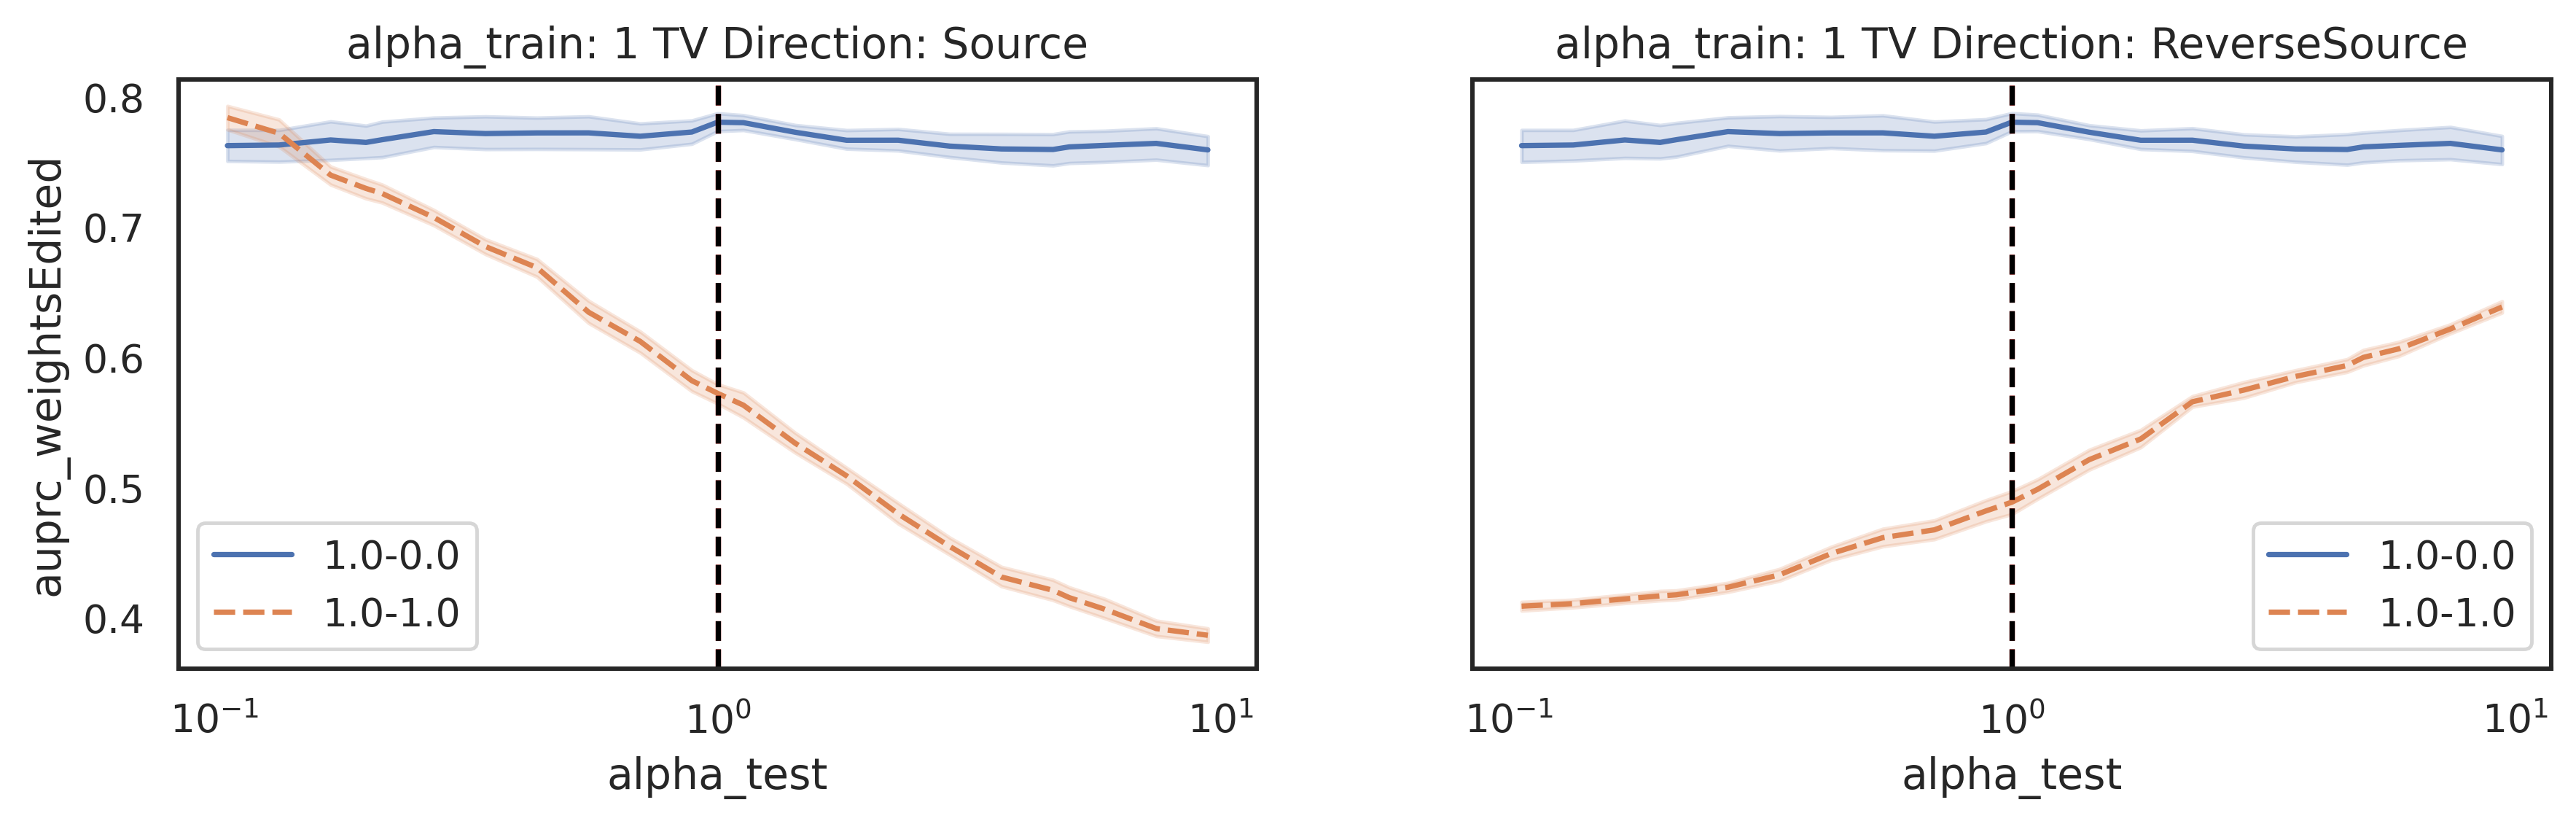

In [193]:
_df = deepcopy(df_eval)

_df = _df.query("C_y.isin([0.5])")
_df = _df.query("C_z.isin([0.5])")

df_plt = _df.copy().reset_index(drop=True)

y = "auprc_weightsEdited"




    
for set_i, alpha_train in zip(sets_ls, alpha_train_ls):
    
    fig, ax = plt.subplots(1,2, figsize=(12,3), sharey=True)

    for i,tv_d in enumerate(["Source", "ReverseSource"]):
        
        sns.lineplot(data=df_plt[(df_plt['set'] == set_i) & (df_plt['tv_direction'] == tv_d)], 
                     x="alpha_test", y=y, 
                     style="lambda1_lambda2", ax=ax[i],
                     hue='lambda1_lambda2',
                     # c='orange',
                    )


        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].axvline(1/alpha_train, color="black", linestyle='dashed')

        ax[i].title.set_text("alpha_train: " + str(alpha_train) + " TV Direction: " + tv_d)
        ax[i].legend()


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()


## Summary Plot

### Task Vector Results

In [ ]:
## Two lambdas
# dataset_name = "SHAC"
dataset_name = "HateSpeech"

subdir = "original"
# subdir = "threeLambdas"
# subdir = "ReverseSource"

if dataset_name == "SHAC":
    outdir =f"../output/tmpData/SHAC/summary/{subdir}"
    set_levels = [11063,6114,1152]
    
    if subdir == 'original':
        lambda_levels = ["1.0-0.0", "1.05-0.05", "1.1-0.1", "1.3-0.3", "1.5-0.5", "1.7-0.7", "2.0-1.0", "3.0-2.0", "4.0-3.0"]  # discard 1.0-1.0
        # lambda_levels = ["1.0-0.0", "1.5-0.5"]
        lambdaVar = "lambda1_lambda2"
        hue_kws={}
    elif subdir == 'ReverseSource':
        lambda_levels = ["1.0-0.0", "1.05-0.05", "1.1-0.1", "1.3-0.3", "1.5-0.5", "1.7-0.7", "2.0-1.0", "1.0-1.0"]
        # lambda_levels = ["1.0-0.0", "1.5-0.5"]
        lambdaVar = "lambda1_lambda2"
        hue_kws={}
    elif subdir == 'threeLambdas':
        lambda_levels = ["1.0-0.0-0.0","2.0-1.0-0.0","2.0-0.0-1.0", "1.6-0.3-0.3", "2.0-0.5-0.5", "2.6-0.8-0.8", "3.0-1.0-1.0"]
        # lambda_levels = ["1.6-0.3-0.3"]
        lambdaVar = "lambda1_lambda2_lambda3"
        hue_kws={"marker" : ["o","D","X","o","o","o","o"]}
        
    
elif dataset_name == "HateSpeech":
    outdir = f"../output/tmpData/HateSpeech/summary/{subdir}"
    set_levels = [9870, 6126, 1874]
    lambda_levels = ["1.0-0.0", "1.05-0.05", "1.1-0.1", "1.3-0.3", "1.7-0.7", "2.0-1.0", "3.0-2.0", "4.0-3.0"]
    
    lambdaVar = "lambda1_lambda2"
    hue_kws={}
    
df_list = []
for file_i in Path(outdir).glob("Eval-*"):
    tmpdf = pd.read_csv(file_i)
    df_list.append(tmpdf)
        

        
df_summary = pd.concat(df_list).reset_index(drop=True)

if subdir == "threeLambdas":
    df_summary["lambda1_lambda2_lambda3"] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}-{x['lambda3']}", axis=1)
else:
    df_summary[lambdaVar] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}", axis=1)

df_summary[lambdaVar] = pd.Categorical(df_summary[lambdaVar], categories=lambda_levels)

In [ ]:
df_summary

In [ ]:
df_summary['set'] = pd.Categorical(df_summary['set'], categories=set_levels)

In [ ]:
df_summary['cy'].unique()

In [ ]:
sns.set_theme()
sns.set_context("paper")

In [ ]:
my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.set(xlabel="AUPRC @ predMidpoint")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_min", "coef")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.1])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train", "coef")
g.set(xlabel=r"AUPRC @ Best $\alpha_{test}$")

g.add_legend()
# g.set(ylim=(-0.025,0.025))
# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary[lambdaVar].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
# g.set(ylim=(-0.025,0.025))
# # g.set(ylim=(-0.04,0.04))
g.set(ylim=(-0.3,0.15))
# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')



my_palette = sns.color_palette("crest", df_summary['cy'].nunique())

g = sns.FacetGrid(data=df_summary, row=lambdaVar, col='set', hue='cy', height=3, palette=my_palette)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.map(plt.axhline, y=0, ls='--', c='red')

### Task Vector Mix Source Results (Main)

In [3]:
# ##### HateSpeech
# files_original = [
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/original/Eval-set-566-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_2.0-added-ntest_200-Runs_5.csv",
    
# ]
# files_reverseSource = [
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/HateSpeech/summary/ReverseSource/Eval-set-6621-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_2.0-added-ntest_200-Runs_5.csv",
    
# ]


##### SHAC
# files_original = [
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/original/Eval-set-1152-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_2.0-added-ntest_200-Runs_5.csv",
# ]
# files_reverseSource = [
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_0.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.0-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.25-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.5-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_1.75-added-ntest_200-Runs_5.csv",
#     "../output/tmpData/SHAC/summary/ReverseSource/Eval-set-11063-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.5-lambda2_2.0-added-ntest_200-Runs_5.csv",
# ]

# dataset_name = "SHAC"
# set1 = 1152
# set2 = 11063
# 11063
# set1 = set2 = 6114

# dataset_name = "HateSpeech"
dataset_name = "CD"
set1 = 566
set2 = 6621

set1 = set2 = 3636

lambda2_ls = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']

# modelUsed = "Llama"
modelUsed = "RoBERTa"

if modelUsed == "Llama":
    ## llama2
    original_template = "../output/tmpData/{}/summary/original/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
    reverse_template = "../output/tmpData/{}/summary/ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
elif modelUsed == "RoBERTa":
    # roberta
    original_template = "../output/roberta/{}/summary/original/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
    reverse_template = "../output/roberta/{}/summary/ReverseSource/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"


#### for 1.5 setting
# lambda2_ls = ['0.0', '0.25', '0.5', '0.75', '1.0', '1.25', '1.5', '1.75', '2.0', '2.5','3.0']
# files_original = [original_template.format(dataset_name, s, 1.5, l2) for s, l2 in itertools.product([set1], lambda2_ls)]
# files_reverseSource = [reverse_template.format(dataset_name, s, 1.5, l2) for s, l2 in itertools.product([set2], lambda2_ls)]

# files_original.extend([original_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set1], [1.0,0.0])])
# files_reverseSource.extend([reverse_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set2], [1.0,0.0])])


#### for 1.0 setting
files_original = [original_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set1], lambda2_ls)]
files_reverseSource = [reverse_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set2], lambda2_ls)]

    
df_list = []
for dirx,sr in zip([files_original, files_reverseSource], ['Source','ReverseSource']):
    for file_i in dirx:
        tmpdf = pd.read_csv(file_i)
        # tmpdf['model'] = dirx.split("/")[-1]
        tmpdf = tmpdf.assign(set = tmpdf['set'].astype(str) + "-" + sr)
        df_list.append(tmpdf)
        

        
df_summary = pd.concat(df_list).reset_index(drop=True)


In [4]:
lambdaVar = "lambda1_lambda2"
# lambda_levels = ["1.5-0.0", "1.5-0.25", "1.5-0.5", "1.5-0.75", "1.5-1.0", "1.5-1.25", "1.5-1.5", "1.5-1.75", "1.5-2.0", "1.5-2.5", "1.5-3.0"]

# lambda_levels = ["1.0-0.0", "1.0-1.0", "1.5-0.0", "1.5-0.25", "1.5-0.5", "1.5-0.75", "1.5-1.0", "1.5-1.25", "1.5-1.5", "1.5-1.75", "1.5-2.0", "1.5-2.5", "1.5-3.0"]

lambda_levels = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-0.8", "1.0-1.0", "1.0-1.2", "1.0-1.4", "1.0-1.6", "1.0-1.8", "1.0-2.0", ]

df_summary[lambdaVar] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}", axis=1)

df_summary[lambdaVar] = pd.Categorical(df_summary[lambdaVar], categories=lambda_levels)

In [5]:
#### for 1.5 setting
# my_palette = sns.color_palette("tab10", 2)[::-1] + sns.color_palette("rocket_r", (df_summary[lambdaVar].nunique()-2))

# hue_kws={"marker" : ["X","D"] + ["o"]*(len(lambda_levels)-2), 
#          # "s":[14]*len(lambda_levels)
#         }


#### for 1.0 setting
my_palette = sns.color_palette("rocket_r", (df_summary[lambdaVar].nunique()))
plt_extra = sns.color_palette("tab10", 2)[::-1]


markers = ["o"]*(len(lambda_levels))
for idx,l in enumerate(lambda_levels):
    if l == "1.0-0.0":
        markers[idx] = "X"
        my_palette[idx] = plt_extra[0]
    elif l == "1.0-1.0":
        markers[idx] = "D"
        my_palette[idx] = plt_extra[1]
hue_kws={"marker" : markers, 
         # "s":[14]*len(lambda_levels)
        }

# hue_kws={}

In [6]:
if modelUsed == "Llama":
    ## llama 2
    if dataset_name == "SHAC":
        ylim = (-0.17,0.17)
        xlim=(0.28,1.02)
    elif dataset_name == "CD":
        # ylim = (-0.35,0.35)
        # xlim = (0.28, 1.02)

        ylim = (-0.34,0.34)
        xlim = (0.38, 1.02)
    elif dataset_name == "HateSpeech":
        ylim = (-0.32,0.32)
        xlim = (0.38,1.02)
elif modelUsed == "RoBERTa":
    ## roberta
    if dataset_name == "SHAC":
        ylim = (-0.11,0.11)
        xlim=(0.68,1.02)
        if set1 == set2 == 6114:
            ylim = (-0.042,0.042)
            xlim=(0.84,1.02)
    elif dataset_name == "CD":
        ylim = (-0.23,0.23)
        xlim = (0.58, 1.02)
        if set1 == set2 == 3636:
            ylim = (-0.13,0.13)
            xlim=(0.68,1.02)
    elif dataset_name == "HateSpeech":
        ylim = (-0.32,0.32)
        xlim = (0.38,1.02)
        if set1 == set2 == 3636:
            ylim = (-0.11,0.11)
            xlim=(0.58,1.02)
        
    
    
    

In [7]:
sns.set_theme(rc={"figure.dpi": 350})
sns.set_context("paper")
# sns.set_theme(style='white')

In [8]:
df_summary.columns

Index(['Unnamed: 0', 'cy', 'coef', 'predMidpoint', 'pred_lower', 'pred_upper',
       'pred_se', 'coef_lower', 'coef_upper', 'y_min', 'y_alpha_train',
       'y_alpha_train_recip', 'y_alpha_train_1', 'name', 'set', 'lambda1',
       'lambda2', 'pred_lowerdiff', 'pred_upperdiff', 'coef_lowerdiff',
       'coef_upperdiff', 'lambda1_lambda2'],
      dtype='object')

In [781]:
#####  For Save Only!! 
###   Save Plot: Worst alpha
# savefig = False
savefig = False


outname = f"../output/TaskVectorFigs/fig_ScalingLambdas_WorstAlpha_{dataset_name}_{modelUsed}_Set1_{set1}_Set2_{set2}_Cy_0.5.png"

_df_plt = deepcopy(df_summary.query("cy.isin([0.5])"))

if set1 == set2:
    _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=[f'{set1}-ReverseSource', f'{set1}-Source'])
else:
    if dataset_name in ["CD", "HateSpeech"]:
        _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['6621-ReverseSource', '566-Source'])
    elif dataset_name in ["SHAC"]:
        _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['11063-ReverseSource', '1152-Source'])
    

g = sns.FacetGrid(data=_df_plt, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws, height=3.3)
g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
# g.set(ylim=(-0.25,0.25))
# # g.set(ylim=(-0.04,0.04))
# g.set(ylim=(-0.3,0.15))
# g.set(ylim=(-0.17,0.17))
# g.set(ylim=(-0.33,0.33))

g.set(ylim=ylim)
g.set(xlim=xlim)

# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

axes = g.axes.flatten()
for ax in axes:
    if  ("6621-ReverseSource" in ax.title.get_text()) or ("11063-ReverseSource" in ax.title.get_text()):
        ax.set_title(r"$\alpha_{train}=0.2$")
    elif ("566-Source" in ax.title.get_text()) or ("1152-Source" in ax.title.get_text()):
        ax.set_title(r"$\alpha_{train}=5$")
    elif ("3636" in ax.title.get_text()) or ("6114" in ax.title.get_text()):
        if "-Source" in ax.title.get_text():
            ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_2)$]")
        elif "-ReverseSource" in ax.title.get_text():
            ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_1)$]")
        
g.set_ylabels("Coefficient")

# plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [ ]:
# g = sns.FacetGrid(data=df_summary, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g = sns.FacetGrid(data=df_summary, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)

g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()

g.hue_kws = {}

g.map(plt.axhline, y=0, ls='--', c='red')

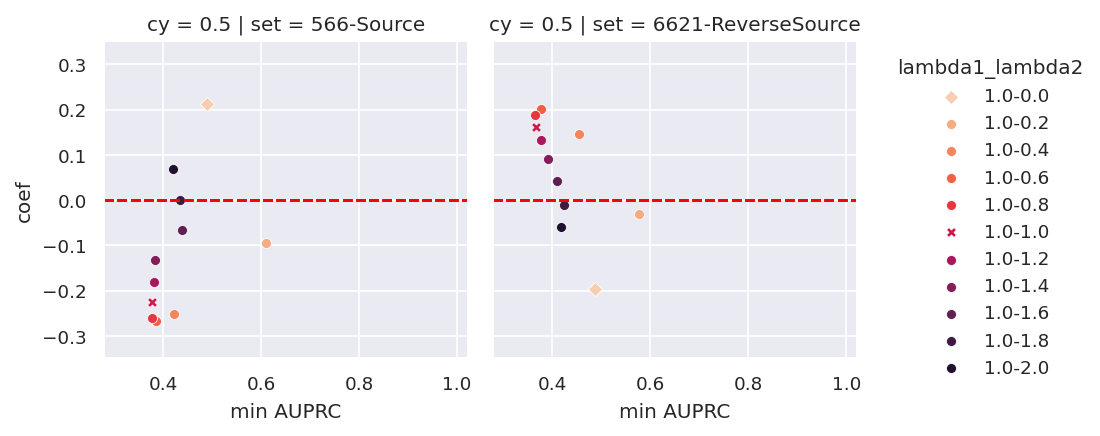

In [115]:
g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)

g.map(sns.scatterplot, "y_min", "coef")
g.set(xlabel=r"min AUPRC")

g.add_legend()

# g.set(ylim=(-0.25,0.25))
# g.set(ylim=(-0.33,0.33))
# g.set(xlim=(0.90,1))
g.set(ylim=ylim)
g.set(xlim=xlim)

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

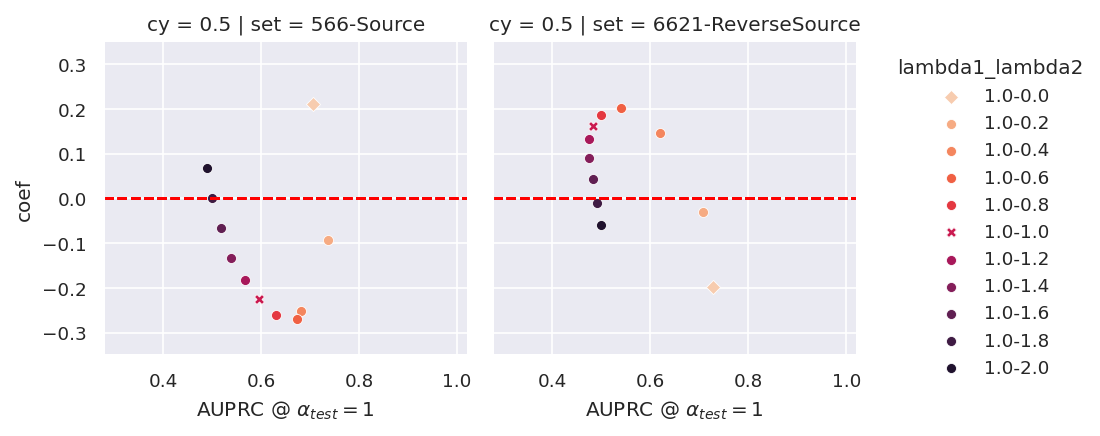

In [116]:

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train_1", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ $\alpha_{test}=1$")
# g.set(ylim=(-0.25,0.25))
# # g.set(ylim=(-0.04,0.04))
# g.set(ylim=(-0.3,0.15))
# g.set(ylim=(-0.17,0.17))
# g.set(ylim=(-0.33,0.33))

g.set(ylim=ylim)
g.set(xlim=xlim)

# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

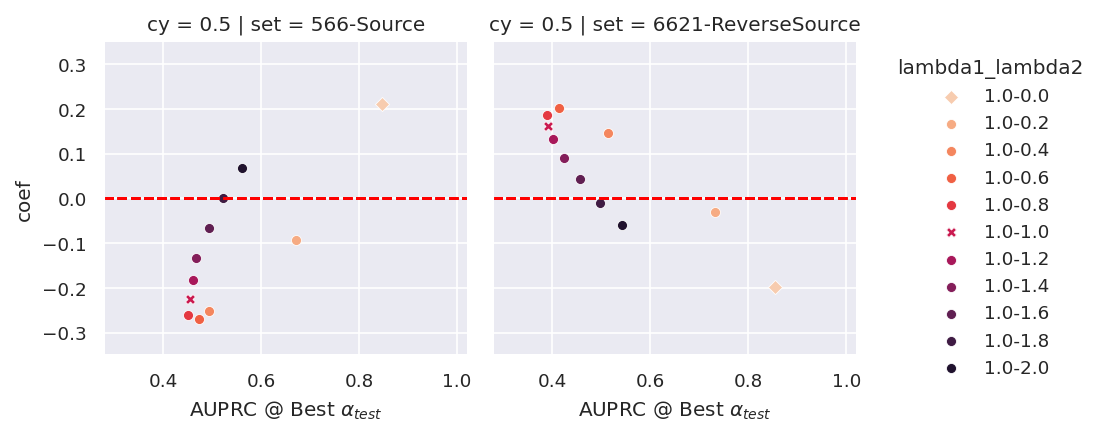

In [117]:

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train", "coef")
g.set(xlabel=r"AUPRC @ Best $\alpha_{test}$")

g.add_legend()

# g.set(ylim=(-0.25,0.25))
# g.set(ylim=(-0.33,0.33))
# g.set(xlim=(0.90,1))
g.set(ylim=ylim)
g.set(xlim=xlim)

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

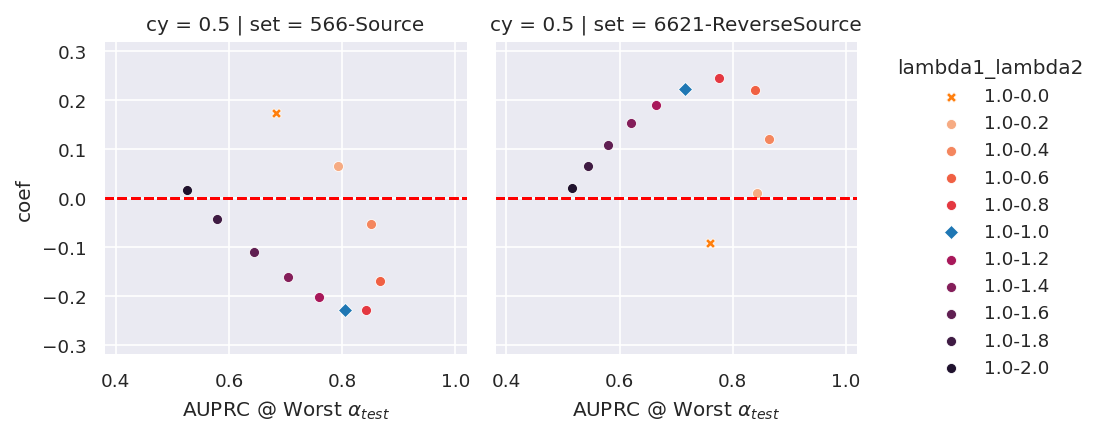

In [374]:

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
# g.set(ylim=(-0.25,0.25))
# # g.set(ylim=(-0.04,0.04))
# g.set(ylim=(-0.3,0.15))
# g.set(ylim=(-0.17,0.17))
# g.set(ylim=(-0.33,0.33))

g.set(ylim=ylim)
g.set(xlim=xlim)

# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')
plt.show()

In [ ]:
### abs of Worst
df_plt = deepcopy(df_summary.query("cy.isin([0.5])"))
df_plt['coef'] = df_plt['coef'].abs()

g = sns.FacetGrid(data=df_plt, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
# g.set(ylim=(-0.025,0.025))
# # g.set(ylim=(-0.04,0.04))
# g.set(ylim=(-0.3,0.15))
# g.set(ylim=(-0.17,0.17))
# g.set(ylim=(-0.33,0.33))

# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')
plt.show()

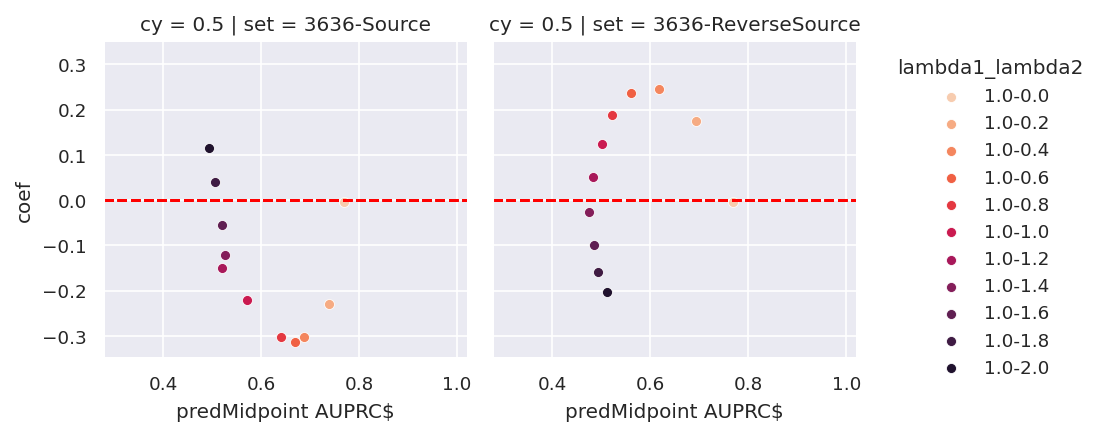

In [38]:

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.set(xlabel=r"predMidpoint AUPRC$")

g.add_legend()

# g.set(ylim=(-0.25,0.25))
# g.set(ylim=(-0.33,0.33))
# g.set(xlim=(0.90,1))
g.set(ylim=ylim)
g.set(xlim=xlim)

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# set_ls = [566]
set_ls = [6621]
# set_ls = [3636]

In [ ]:
# original_template = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.pkl"
original_template = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.pkl"

In [ ]:
lambda2_ls = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']
fnames = [original_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product(set_ls, lambda2_ls)]

In [ ]:
fnames

In [ ]:
df_ls = []
for s in set_ls:
    for lm2 in lambda2_ls:
        with open(original_template.format(dataset_name, s, 1.0, lm2), "rb") as f:
            tmp = pickle.load(file=f)
            tmp['lambda2'] = lm2
            tmp['set'] = s
            if s == 566:
                tmp['alpha_train'] = 5
            elif s == 6621:
                tmp['alpha_train'] = 0.2
            elif s == 3636:
                tmp['alpha_train'] = 1
            df_ls.append(tmp)
            

In [ ]:
df_eval = pd.concat(df_ls)

In [ ]:
lambdaVar = "lambda1_lambda2"
# lambda_levels = ["1.5-0.0", "1.5-0.25", "1.5-0.5", "1.5-0.75", "1.5-1.0", "1.5-1.25", "1.5-1.5", "1.5-1.75", "1.5-2.0", "1.5-2.5", "1.5-3.0"]

# lambda_levels = ["1.0-0.0", "1.0-1.0", "1.5-0.0", "1.5-0.25", "1.5-0.5", "1.5-0.75", "1.5-1.0", "1.5-1.25", "1.5-1.5", "1.5-1.75", "1.5-2.0", "1.5-2.5", "1.5-3.0"]

lambda_levels = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-0.8", "1.0-1.0", "1.0-1.2", "1.0-1.4", "1.0-1.6", "1.0-1.8", "1.0-2.0", ]

df_eval[lambdaVar] = df_eval.apply(lambda x: f"1.0-{x['lambda2']}", axis=1)

df_eval[lambdaVar] = pd.Categorical(df_eval[lambdaVar], categories=lambda_levels)

my_palette = sns.color_palette("rocket_r", df_eval[lambdaVar].nunique())

In [ ]:
df_eval.columns

In [ ]:
_df = deepcopy(df_eval)
_df['C_y'] = _df['C_y'].round(1)

# _df = _df.query("C_y == 0.5")
_df = _df.query("C_z == 0.5")


for cy in sorted(set(_df['C_y'])):
    
    y_ls = ['auprc_weightsEdited','auprc_weightsEdited_df0','auprc_weightsEdited_df1']

    fig, ax = plt.subplots(1,len(y_ls), figsize=(18,3), sharey=True)
    
    for i,_y in enumerate(y_ls):
        # sns.lineplot(data=_df[(_df['C_z'] == cz) ], x='alpha_test', y=_y, #style='alpha_train', 
        #          hue='lambda2',
        #          ax=ax[i])
        sns.lineplot(data=_df[(_df['C_y'] == cy) ], x='alpha_test', y=_y, #style='alpha_train', 
                 hue='lambda2',
                 ax=ax[i],
                 palette=my_palette,
                    )
        
        ax[i].set_xscale('log')
        # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        # ax[i].title.set_text(_y + " alpha_train: " + str(alpha_train) + " C_z: " + str(cz))
        # ax[i].title.set_text(_y + " " + "C_z: " + f"{cz:.2f}")
        ax[i].title.set_text(_y + " " + "C_y: " + f"{cy:.2f}")

        ax[i].set_ylabel(_y.split("_")[0])

        # ax[i].set_ylim(0.8,1.02)


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

        

In [ ]:
_df = deepcopy(df_eval)
_df['C_y'] = _df['C_y'].round(2)

_df = _df.query("C_y == 0.5")


for cz in sorted(set(_df['C_z'])):
    
    y_ls = ['calibration_weightsEdited','calibration_weightsEdited_df0','calibration_weightsEdited_df1']

    fig, ax = plt.subplots(1,len(y_ls), figsize=(18,3), sharey=True)
    
    for i,_y in enumerate(y_ls):
        sns.lineplot(data=_df[(_df['C_z'] == cz) ], x='alpha_test', y=_y, #style='alpha_train', 
                     hue='lambda2',
                     palette=my_palette,
                     ax=ax[i]
                    )
       
        
        ax[i].set_xscale('log')
        # ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].axhline(1, color="red", linestyle='dashed')
        # ax[i].axvline(reciprocal, color="red", linestyle='solid')
        # ax[i].title.set_text(_y + " alpha_train: " + str(alpha_train) + " C_z: " + str(cz))
        # ax[i].title.set_text(_y + " " + "C_z: " + f"{cz:.2f}")
        ax[i].title.set_text(_y + " " + "C_z: " + f"{cz:.2f}")

        ax[i].set_ylabel(_y.split("_")[0])

        # ax[i].set_ylim(0.8,1.02)


    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

        

### Task Vector Mix Model Results

In [ ]:
files_proj = f"../output/tmpData/SHAC/summary/threeLambdas_proj"
files_norm_proj = f"../output/tmpData/SHAC/summary/threeLambdas_norm_proj"
files_norm = f"../output/tmpData/SHAC/summary/threeLambdas_norm"
files_original = f"../output/tmpData/SHAC/summary/threeLambdas"


df_list = []
for dirx in [files_proj, files_norm_proj, files_norm, files_original]:
    for file_i in Path(dirx).glob("Eval-*"):
        tmpdf = pd.read_csv(file_i)
        tmpdf['model'] = dirx.split("/")[-1]
        df_list.append(tmpdf)
        

        
df_summary = pd.concat(df_list).reset_index(drop=True)


In [ ]:
# files_proj = f"../output/tmpData/HateSpeech/summary/threeLambdas_proj"
files_norm_proj = f"../output/tmpData/HateSpeech/summary/threeLambdas_norm_proj"
# files_norm = f"../output/tmpData/HateSpeech/summary/threeLambdas_norm"
files_original = f"../output/tmpData/HateSpeech/summary/threeLambdas"


    
df_list = []
for dirx in [files_norm_proj, files_original]:
    for file_i in Path(dirx).glob("Eval-*"):
        tmpdf = pd.read_csv(file_i)
        tmpdf['model'] = dirx.split("/")[-1]
        df_list.append(tmpdf)
        

        
df_summary = pd.concat(df_list).reset_index(drop=True)


In [ ]:
pd.reset_option('display.max_rows')

In [ ]:
df_summary = df_summary.query("(lambda1 == 1.5)").reset_index(drop=True)

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary['model'].nunique())

g = sns.FacetGrid(data=df_summary, row='cy', col='set', hue='model', 
                  palette=my_palette, 
                  # hue_kws=hue_kws
                 )

g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
# # g.set(ylim=(-0.025,0.025))
# # # g.set(ylim=(-0.04,0.04))
# g.set(ylim=(-0.3,0.15))
# # g.set(xlim=(0.90,1))

# g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary['model'].nunique())

g = sns.FacetGrid(data=df_summary.query("cy==0.5"), row='cy', col='set', hue='model', 
                  palette=my_palette, 
                  # hue_kws=hue_kws
                 )

g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
# # g.set(ylim=(-0.025,0.025))
# # # g.set(ylim=(-0.04,0.04))
# g.set(ylim=(-0.3,0.15))
# # g.set(xlim=(0.90,1))

# g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

### LoRA Fine Tune - Many R and Model Size Results

In [ ]:
outdir = "../output/tmpData/SHAC/summary/loras"
for file_i in Path(outdir).glob("LoRA_*"):
    print(file_i)

In [ ]:
dataset_name = "SHAC"
# dataset_name = "HateSpeech"

if dataset_name == "SHAC":
    outdir = "../output/tmpData/SHAC/summary/loras"
    modelsize_levels = ["7B", "13B", "70B"]
    loraR_levels = [2,8,32,64]

df_list = []
for file_i in Path(outdir).glob("LoRA_*"):
    tmpdf = pd.read_csv(file_i)
    df_list.append(tmpdf)

In [ ]:
df_summary = pd.concat(df_list)

In [ ]:
df_summary

In [ ]:
df_summary['model_size'] = pd.Categorical(df_summary['model_size'], categories=modelsize_levels)

df_summary['loraR'] = pd.Categorical(df_summary['loraR'], categories=loraR_levels)

In [ ]:
df_summary['cy'].unique()

In [ ]:
# sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')

my_palette = sns.color_palette("rocket_r", df_summary['loraR'].nunique())

g = sns.FacetGrid(data=df_summary, row='cy', col='model_size', hue='loraR', palette=my_palette)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.add_legend()

g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
my_palette = sns.color_palette("rocket_r", df_summary["loraR"].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='model_size', hue="loraR", palette=my_palette)
g.map(sns.scatterplot, "predMidpoint", "coef")
g.set(xlabel="AUPRC @ predMidpoint")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
my_palette = sns.color_palette("rocket_r", df_summary["loraR"].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='model_size', hue="loraR", palette=my_palette)
g.map(sns.scatterplot, "y_min", "coef")
g.add_legend()

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
my_palette = sns.color_palette("rocket_r", df_summary["loraR"].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='model_size', hue="loraR", palette=my_palette)
g.map(sns.scatterplot, "y_alpha_train", "coef")
g.set(xlabel=r"AUPRC @ Best $\alpha_{test}$")

g.add_legend()
# g.set(ylim=(-0.025,0.025))
# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
my_palette = sns.color_palette("rocket_r", df_summary["loraR"].nunique())

g = sns.FacetGrid(data=df_summary.query("cy.isin([0.5])"), row='cy', col='model_size', hue="loraR", palette=my_palette)
g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
g.add_legend()
g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
# g.set(ylim=(-0.025,0.025))
# # g.set(ylim=(-0.04,0.04))
# g.set(ylim=(-0.3,0.15))
# g.set(xlim=(0.90,1))

g.hue_kws = {}
g.map(plt.axhline, y=0, ls='--', c='red')

In [ ]:
from sklearn.preprocessing import minmax_scale

colors_ = range(df_summary['cy'].nunique())
discrete_colors = sample_colorscale('Bluered', minmax_scale(colors_))


In [ ]:

fig = px.scatter(df_summary, x="predMidpoint", y="coef", 
                 error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 error_y="coef_lowerdiff", error_y_minus="coef_upperdiff",
                 color="cy", facet_col="loraR", facet_row="model_size",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 color_continuous_scale=px.colors.sequential.Emrld,
                 # color_discrete_sequence=discrete_colors,
                 width=1400, height=1000,
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
              
              
fig.show()



In [ ]:

n_colors=len(loraR_levels) + 1  # discard 1st color, since it's too faint
my_palette = px.colors.sample_colorscale("deep", [n/(n_colors -1) for n in range(n_colors)])[1:]

fig = px.scatter(df_summary.query("cy==0.5"), 
                 x="predMidpoint", y="coef", 
                 error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 error_y="coef_lowerdiff", error_y_minus="coef_upperdiff",
                 color="loraR", facet_col="model_size", facet_row="cy",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 # color_continuous_scale=px.colors.sequential.Emrld,
                 color_discrete_sequence=my_palette,
                 width=1000, height=400,
                 
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
              
              
fig.show()



In [ ]:

n_colors=len(loraR_levels) + 1  # discard 1st color, since it's too faint
my_palette = px.colors.sample_colorscale("deep", [n/(n_colors -1) for n in range(n_colors)])[1:]

fig = px.scatter(df_summary.query("cy.isin( [0.3,0.5,0.7] )"), 
                 x="y_min", y="coef", 
                 # error_x="pred_lowerdiff", error_x_minus="pred_upperdiff",
                 
                 color="loraR", facet_col="model_size", facet_row="cy",
                 category_orders={'loraR':loraR_levels, 'model_size':modelsize_levels},
                 # color_continuous_scale=px.colors.sequential.Emrld,
                 color_discrete_sequence=my_palette,
                 width=1000, height=800,
                 
                )

fig.add_hline(y=0, line_dash="dot", line_color='Red')
fig.update_traces(marker={'size': 12, 'opacity':0.8})      
              
fig.show()



In [ ]:
pd.factorize(df_summary['cy'])

In [ ]:
# # sns.lineplot(df_summary, x="predMidpoint", y="coef", hue='cy')
# import matplotlib as mpl

# # cmap=mpl.colormaps["Purples"]
# cmap = plt.cm.get_cmap('Purples', 10)
# grp = df_summary.groupby(['model_size', 'loraR'])

# my_palette = sns.color_palette("crest", df_summary['cy'].nunique(), as_cmap=True)


# fig, ax = plt.subplots(df_summary['model_size'].nunique(), df_summary['loraR'].nunique(), figsize=(20,16), sharey=True)

# ax = ax.ravel()
# for idx, item in enumerate(grp):
    
    
#     ax[idx].errorbar(item[1]['predMidpoint'], item[1]['coef'],
#                      xerr=[item[1]['pred_lowerdiff'], item[1]['pred_upperdiff']],
#                      yerr=[item[1]['coef_lowerdiff'], item[1]['coef_upperdiff']],
#                      # lolims=item[1]['pred_lower'], uplims=item[1]['pred_upper'], 
#                      fmt='o',
#                      # marker='o', linestyle="none",
#                      color='red',
#                     )
    
    
    
    
# ax.errorbar(x, y + 1.5, xerr=xerr, yerr=yerr,
#             lolims=lolims, uplims=uplims,
#             marker='o', markersize=8,
#             linestyle=ls)    
# for item, color in zip(1, palette):
#     print(item)
#     _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
#     g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
#     g_results.set(xscale="log")
    
#     ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
#     ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
#     ax[idx].legend()
#     ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
#     sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
#     g_results.set(xticks=sample_count)
#     g_results.set(xticklabels=sample_count)

# plt.tight_layout()


# g = sns.FacetGrid(data=df_summary, row='model_size', col='loraR', hue='cy', height=3, palette=my_palette)
# g.map(sns.scatterplot, "predMidpoint", "coef")
# g.add_legend()

# g.map(plt.axhline, y=0, ls='--', c='red')

## Scatter Plot

In [ ]:

fig, ax = plt.subplots(1,2, figsize=(28,10))
xlabel = "distance_KL_Test_Train"
_df = df.sort_values(xlabel)

for idx, k in enumerate(["auprc_logistic_vanilla", "auprc_logistic_confounder"]):
    
    im = ax[idx].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], c=_df[k], cmap='Blues')
    im.set_clim(0.8,1)
    ax[idx].set_xlabel("p_pos_test_z0")
    ax[idx].set_ylabel("p_pos_test_z1")
    ax[idx].set_title(k)

    fig.colorbar(im, ax=ax[idx])

In [ ]:
pd.options.display.max_columns = None

In [ ]:

df[(df['p_pos_test_z0'].round(3)==0.3)
    & (df['p_pos_test_z1'].round(2)==0.3) 
    & (df['run']==0) 
    # & (df['p_mix_z1'].round(3)==0.4)
   ]


In [ ]:
sns.scatterplot(x="p_pos_test_z0", y="p_pos_test_z1", data=df.query("(run==0)"))

In [ ]:

auprc_vanilla_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==0.4)
                           & (_df['run']==0)]['auprc_logistic_vanilla'].values[0]


In [ ]:
auprc_vanilla_target

In [ ]:
df[
    (df['run']==0) 
    # & (df['p_mix_z1'].round(3)==0.4)
    & (df['p_pos_test_z0'].round(3) == 0.5)
    & (df['p_pos_test_z1'].round(3) == 0.2)
   ]

In [ ]:
min(auprc_ba_target - _df["auprc_logistic_confounder"])

In [ ]:
max(auprc_vanilla_target - _df["auprc_logistic_vanilla"])

In [ ]:
from matplotlib import cm

fig, ax = plt.subplots(1,2, figsize=(7,3),dpi=400)
# xlabel = "distance_KL_Test_Train"



p_mix_z1 = 0.4
_df = df[
    (df['run']==0) 
    & (df['p_mix_z1'].round(3)==p_mix_z1)
   ].copy()






auprc_vanilla_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==p_mix_z1)
                           & (_df['run']==0)]['auprc_logistic_vanilla'].values[0]


auprc_ba_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==p_mix_z1)
                           & (_df['run']==0)]['auprc_logistic_confounder'].values[0]


im = ax[0].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], 
                   c=abs(auprc_vanilla_target - _df["auprc_logistic_vanilla"]), cmap='Blues',
                   s=2
                  )
im.set_clim(0,0.2)
ax[0].set(xlabel="p_pos_test_z0", ylabel="p_pos_test_z1", title="AUPRC Difference of vanilla")

fig.colorbar(im, ax=ax[0])



im = ax[1].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], 
                   c=abs(auprc_ba_target - _df["auprc_logistic_confounder"]), cmap='Blues',
                   s=2
                  )
im.set_clim(0,0.2)
ax[1].set(xlabel="p_pos_test_z0", ylabel="p_pos_test_z1", title="AUPRC Difference of BA")
# plt.ylabel("p_pos_test_z1")
# plt.title("AUPRC of BA")

fig.colorbar(im, ax=ax[1])



plt.tight_layout()

In [ ]:
df.query("0.67 < distance_KL_Test_Train < 0.75").sort_values("distance_KL_Test_Train")

## Check some diagnosis

### Corr Plot

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(pd.DataFrame(x_transform_test).iloc[:, :].corr(), vmin=-1, vmax=1)

### R2

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2_score(y_true=y_test, y_pred=y_probs_vanilla[:, 1])

In [ ]:
r2_score(y_true=y_test, y_pred=y_probs_confound[:, 1])

In [ ]:
def r2AndAdjusted(y_true, y_pred, np):
    n = len(y_true)
    
    r2 = r2_score(y_true=y_true, y_pred=y_pred)
    r2_adjusted = 1-(1-r2)*(n-1)/(n-np-1)
    
    return r2, r2_adjusted
    

In [ ]:
r2AndAdjusted(y_true=y_test, y_pred=y_probs_vanilla[:, 1], np=384)

In [ ]:
# auprc_logistic_confounder

# auprc_logistic_vanilla

In [ ]:
x_transform_train.shape

### Deviance Residuals

In [ ]:
def deviance(X, y, model):
    return 2*metrics.log_loss(y, model.predict_proba(X), normalize=False)

In [ ]:
deviance(X=x_transform_test, y=y_test, model=clf_vanilla)

### Calibration

In [ ]:
from sklearn.calibration import calibration_curve
prob_true_vanilla, prob_pred_vanilla = calibration_curve(y_true=y_test, y_prob=y_probs_vanilla[:,1], n_bins=10)
prob_true_confound, prob_pred_confound = calibration_curve(y_true=y_test, y_prob=y_probs_confound[:,1], n_bins=10)


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(prob_pred_vanilla, prob_true_vanilla, label='vanilla')
ax.plot(prob_pred_confound, prob_true_confound, label='confound')

ax.plot([0,1],[0,1], "--", color='gray')
ax.legend()


In [ ]:
from sklearn import metrics


In [ ]:
tmp1 = np.random.uniform(size=10)
# tmp2 = np.random.uniform(size=10)
tmp2 = tmp1 * 0.8

tmpy = np.random.binomial(1, 0.3, 10)

In [ ]:
tmpy

In [ ]:
print(tmp1)
print(tmp2)

In [ ]:
a = 0.56
tmpn = a * tmp1  + (1-a) * tmp2

In [ ]:
metrics.average_precision_score(
                    y_true=tmpy,
                    y_score=tmpn,
                )

In [ ]:
tmpn

In [ ]:
np.argsort(tmpn)

In [ ]:
np.argsort(tmpn)

In [ ]:
ret = {}

In [ ]:
tmp = {'auprc':0.8, 'auroc':0.2, 'f1':0.21}

In [ ]:
for k,v in tmp.items():
    nm = f'{k}_vanilla'
    if nm not in ret:
        ret[nm] = []
    ret[nm].append(v)

In [ ]:
ret

In [ ]:
def getMetrics(a,b):
    return a+b

def appendMetrics(ret, **kws):
    tmp = getMetrics(**kws)
    return tmp + 9

In [ ]:
getMetrics(1,1)

In [ ]:
appendMetrics(ret=[], a=1, b=2)